<a href="https://colab.research.google.com/github/Rohil121/bharat-portfolio-lab/blob/v0.3-robustness-testing/notebooks/03_robustness_testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bharat Portfolio Lab — Robustness Testing

## Version v0.3

This notebook evaluates whether the Adaptive Barbell strategy remains reliable when the testing period, parameters and modelling assumptions change.

### Planned tests

- Development-period versus out-of-sample performance
- Momentum, volatility and trend-window sensitivity
- Transaction-cost stress testing
- Rolling return and risk analysis
- Market-regime performance
- Strategy robustness scoring

The objective is not to find the historically best parameter combination. The objective is to identify whether reasonable alternative assumptions produce broadly consistent results.

## 1. Environment Setup

This section prepares the Python environment for reproducible robustness testing of the Adaptive Barbell strategy.

In [1]:
%pip install -q yfinance

In [2]:
import sys
from importlib.metadata import version
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display settings
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print("v0.3 environment setup complete.")
print("-" * 45)
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Matplotlib: {version('matplotlib')}")
print(f"yfinance: {version('yfinance')}")
print(f"Random seed: {RANDOM_SEED}")

v0.3 environment setup complete.
---------------------------------------------
Python: 3.12.13
pandas: 2.2.2
NumPy: 2.0.2
Matplotlib: 3.10.0
yfinance: 0.2.66
Random seed: 42


## 2. Portfolio and Robustness-Test Configuration

The v0.3 analysis retains the same India 10 flagship portfolio so that the strategy remains comparable with version v0.2.

The historical period is divided into:

- **Development period:** used to examine and establish the strategy rules.
- **Out-of-sample period:** used to evaluate the frozen strategy on later data.

The out-of-sample results will receive greater importance than the full-period results.

In [3]:
# ---------------------------------------------------------
# India 10 Adaptive Barbell portfolio
# ---------------------------------------------------------

portfolio = pd.DataFrame(
    {
        "Company": [
            "HDFC Bank",
            "Tata Consultancy Services",
            "Hindustan Unilever",
            "Sun Pharmaceutical Industries",
            "Power Grid Corporation of India",
            "Bharti Airtel",
            "Larsen & Toubro",
            "Mahindra & Mahindra",
            "Bharat Electronics",
            "Trent",
        ],
        "Ticker": [
            "HDFCBANK.NS",
            "TCS.NS",
            "HINDUNILVR.NS",
            "SUNPHARMA.NS",
            "POWERGRID.NS",
            "BHARTIARTL.NS",
            "LT.NS",
            "M&M.NS",
            "BEL.NS",
            "TRENT.NS",
        ],
        "Sector": [
            "Financial Services",
            "Information Technology",
            "Consumer Staples",
            "Healthcare",
            "Utilities",
            "Telecommunication",
            "Industrials",
            "Automobile",
            "Defence Electronics",
            "Consumer Retail",
        ],
        "Strategy Bucket": [
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Resilient Compounder",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
            "Growth Leader",
        ],
    }
)

portfolio["Initial Weight"] = 1 / len(portfolio)

portfolio_tickers = portfolio["Ticker"].tolist()

resilient_tickers = portfolio.loc[
    portfolio["Strategy Bucket"] == "Resilient Compounder",
    "Ticker",
].tolist()

growth_tickers = portfolio.loc[
    portfolio["Strategy Bucket"] == "Growth Leader",
    "Ticker",
].tolist()


# ---------------------------------------------------------
# Market and portfolio assumptions
# ---------------------------------------------------------

BENCHMARK_TICKER = "^NSEI"
BENCHMARK_NAME = "Nifty 50"

INITIAL_CAPITAL = 1_000_000  # ₹10 lakh
TRADING_DAYS = 252
RISK_FREE_RATE = 0.065

TRANSACTION_COST_RATE = 0.0015


# ---------------------------------------------------------
# Historical testing periods
# ---------------------------------------------------------

DATA_START_DATE = "2016-01-01"

DEVELOPMENT_START_DATE = pd.Timestamp("2016-01-01")
OUT_OF_SAMPLE_START_DATE = pd.Timestamp("2022-01-01")

DOWNLOAD_END_DATE = (
    pd.Timestamp.today().normalize()
    + pd.Timedelta(days=1)
)


# ---------------------------------------------------------
# Frozen v0.2 strategy parameters
# ---------------------------------------------------------

BASE_MOMENTUM_LOOKBACK = 126
BASE_VOLATILITY_LOOKBACK = 63
BASE_TREND_LOOKBACK = 200

BASE_FULL_EQUITY_EXPOSURE = 1.00
BASE_DEFENSIVE_EQUITY_EXPOSURE = 0.70


# ---------------------------------------------------------
# Validation checks
# ---------------------------------------------------------

assert len(portfolio) == 10
assert portfolio["Ticker"].is_unique
assert len(resilient_tickers) == 5
assert len(growth_tickers) == 5
assert np.isclose(portfolio["Initial Weight"].sum(), 1.0)

assert DEVELOPMENT_START_DATE < OUT_OF_SAMPLE_START_DATE
assert 0 <= BASE_DEFENSIVE_EQUITY_EXPOSURE <= 1
assert BASE_FULL_EQUITY_EXPOSURE == 1.0


print("v0.3 configuration completed.")
print("-" * 55)
print(f"Portfolio holdings: {len(portfolio)}")
print(f"Data begins: {DATA_START_DATE}")
print(
    "Development period:",
    f"{DEVELOPMENT_START_DATE.date()} to "
    f"{(OUT_OF_SAMPLE_START_DATE - pd.Timedelta(days=1)).date()}",
)
print(
    "Out-of-sample period:",
    f"{OUT_OF_SAMPLE_START_DATE.date()} onward",
)
print(f"Initial capital: ₹{INITIAL_CAPITAL:,.0f}")
print(f"Base transaction cost: {TRANSACTION_COST_RATE:.2%}")

display(portfolio)

v0.3 configuration completed.
-------------------------------------------------------
Portfolio holdings: 10
Data begins: 2016-01-01
Development period: 2016-01-01 to 2021-12-31
Out-of-sample period: 2022-01-01 onward
Initial capital: ₹1,000,000
Base transaction cost: 0.15%


,Company,Ticker,Sector,Strategy Bucket,Initial Weight
0,HDFC Bank,HDFCBANK.NS,Financial Services,Resilient Compounder,0.1000
1,Tata Consultancy Services,TCS.NS,Information Technology,Resilient Compounder,0.1000
2,Hindustan Unilever,HINDUNILVR.NS,Consumer Staples,Resilient Compounder,0.1000
3,Sun Pharmaceutical Industries,SUNPHARMA.NS,Healthcare,Resilient Compounder,0.1000
4,Power Grid Corporation of India,POWERGRID.NS,Utilities,Resilient Compounder,0.1000
5,Bharti Airtel,BHARTIARTL.NS,Telecommunication,Growth Leader,0.1000
6,Larsen & Toubro,LT.NS,Industrials,Growth Leader,0.1000
7,Mahindra & Mahindra,M&M.NS,Automobile,Growth Leader,0.1000
8,Bharat Electronics,BEL.NS,Defence Electronics,Growth Leader,0.1000
9,Trent,TRENT.NS,Consumer Retail,Growth Leader,0.1000


## 3. Extended Historical Market Data

This section downloads adjusted daily closing prices for the India 10 portfolio and the Nifty 50 benchmark from 2016 onward.

The longer dataset allows the strategy to be tested across multiple market conditions and divided into development and out-of-sample periods.

In [5]:
# ---------------------------------------------------------
# Download adjusted historical prices
# ---------------------------------------------------------

all_tickers = portfolio_tickers + [BENCHMARK_TICKER]

raw_market_data = yf.download(
    tickers=all_tickers,
    start=DATA_START_DATE,
    end=DOWNLOAD_END_DATE.strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False,
    threads=True,
)

if raw_market_data.empty:
    raise ValueError(
        "No market data was downloaded."
    )


# ---------------------------------------------------------
# Extract closing prices
# ---------------------------------------------------------

if isinstance(raw_market_data.columns, pd.MultiIndex):

    if "Close" not in raw_market_data.columns.get_level_values(0):
        raise ValueError(
            "Closing-price data was not returned."
        )

    close_prices = raw_market_data["Close"].copy()

else:

    close_prices = raw_market_data[["Close"]].copy()
    close_prices.columns = all_tickers


# ---------------------------------------------------------
# Arrange and inspect the data
# ---------------------------------------------------------

close_prices = (
    close_prices
    .reindex(columns=all_tickers)
    .sort_index()
)

missing_before_cleaning = (
    close_prices
    .isna()
    .sum()
    .rename("Missing Observations")
)

completely_missing_tickers = (
    close_prices.columns[
        close_prices.isna().all()
    ]
    .tolist()
)

if completely_missing_tickers:
    raise ValueError(
        "No historical data was found for: "
        + ", ".join(completely_missing_tickers)
    )


# Fill only short gaps, then retain fully aligned observations
close_prices = (
    close_prices
    .ffill(limit=3)
    .dropna()
)


# ---------------------------------------------------------
# Separate portfolio and benchmark data
# ---------------------------------------------------------

stock_prices = (
    close_prices[portfolio_tickers]
    .copy()
)

benchmark_prices = (
    close_prices[[BENCHMARK_TICKER]]
    .rename(
        columns={
            BENCHMARK_TICKER: BENCHMARK_NAME
        }
    )
)


# ---------------------------------------------------------
# Validation checks
# ---------------------------------------------------------

assert not close_prices.empty, \
    "The cleaned price dataset is empty."

assert stock_prices.shape[1] == 10, \
    "Data is not available for all 10 portfolio holdings."

assert stock_prices.isna().sum().sum() == 0, \
    "Missing values remain in the stock-price dataset."

assert benchmark_prices.isna().sum().sum() == 0, \
    "Missing values remain in the benchmark dataset."

assert stock_prices.index.equals(
    benchmark_prices.index
), "Stock and benchmark dates are not aligned."

assert close_prices.index.is_monotonic_increasing, \
    "Market dates are not arranged chronologically."

assert close_prices.index.min() < OUT_OF_SAMPLE_START_DATE, \
    "Insufficient data exists before the out-of-sample period."


print("Extended historical data downloaded successfully.")
print("-" * 60)
print(
    f"Requested start date: "
    f"{pd.Timestamp(DATA_START_DATE).date()}"
)
print(
    f"First common observation: "
    f"{close_prices.index.min().date()}"
)
print(
    f"Latest observation: "
    f"{close_prices.index.max().date()}"
)
print(
    f"Total trading observations: "
    f"{len(close_prices):,}"
)
print(
    f"Development observations: "
    f"{(close_prices.index < OUT_OF_SAMPLE_START_DATE).sum():,}"
)
print(
    f"Out-of-sample observations: "
    f"{(close_prices.index >= OUT_OF_SAMPLE_START_DATE).sum():,}"
)

print("\nMissing observations before cleaning:")
display(
    missing_before_cleaning.to_frame()
)

print("\nLatest adjusted closing prices:")
display(
    close_prices.tail()
)

Extended historical data downloaded successfully.
------------------------------------------------------------
Requested start date: 2016-01-01
First common observation: 2016-01-04
Latest observation: 2026-07-30
Total trading observations: 2,614
Development observations: 1,481
Out-of-sample observations: 1,133

Missing observations before cleaning:


,Missing Observations
Ticker,
HDFCBANK.NS,0
TCS.NS,0
HINDUNILVR.NS,0
SUNPHARMA.NS,0
POWERGRID.NS,0
BHARTIARTL.NS,0
LT.NS,0
M&M.NS,0
BEL.NS,0



Latest adjusted closing prices:


Ticker,HDFCBANK.NS,TCS.NS,HINDUNILVR.NS,SUNPHARMA.NS,POWERGRID.NS,BHARTIARTL.NS,LT.NS,M&M.NS,BEL.NS,TRENT.NS,^NSEI
Date,,,,,,,,,,,
2026-07-24,742.8000,"2,254.3000","2,145.0000","1,941.1000",288.2000,"1,898.2000","3,785.6001","3,161.3999",405.0000,"2,890.5000","23,767.4492"
2026-07-27,739.5500,"2,295.6001","2,174.6001","1,973.7000",288.8500,"1,905.3000","3,806.0000","3,238.6001",407.1500,"2,938.3000","23,995.9492"
2026-07-28,735.4000,"2,398.0000","2,022.7000","1,976.7000",285.3000,"1,901.8000","3,832.0000","3,271.2000",389.0000,"2,930.7000","23,985.3496"
2026-07-29,748.2000,"2,446.6001","2,117.8000","1,989.9000",282.8500,"1,950.2000","3,931.3999","3,221.8000",387.5500,"3,005.2000","24,250.1992"
2026-07-30,753.9500,"2,431.8000","2,107.8999","2,001.1000",285.7000,"1,956.8000","3,937.7000","3,283.7000",384.9000,"2,999.2000","24,317.1504"


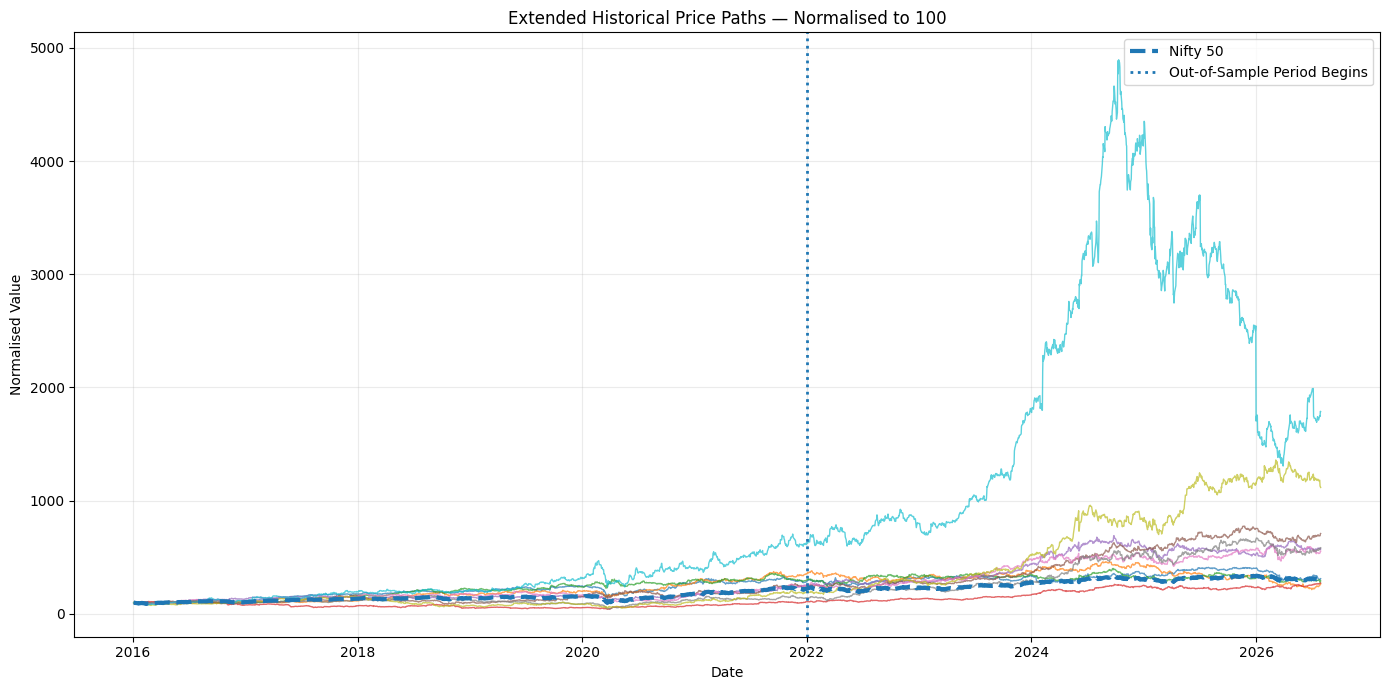

In [6]:
# ---------------------------------------------------------
# Visual validation of the extended dataset
# ---------------------------------------------------------

normalised_prices = (
    close_prices
    .div(close_prices.iloc[0])
    .mul(100)
)

plt.figure(figsize=(14, 7))

for ticker in portfolio_tickers:

    plt.plot(
        normalised_prices.index,
        normalised_prices[ticker],
        linewidth=1,
        alpha=0.70,
    )

plt.plot(
    normalised_prices.index,
    normalised_prices[BENCHMARK_TICKER],
    linewidth=3,
    linestyle="--",
    label=BENCHMARK_NAME,
)

plt.axvline(
    OUT_OF_SAMPLE_START_DATE,
    linewidth=2,
    linestyle=":",
    label="Out-of-Sample Period Begins",
)

plt.title(
    "Extended Historical Price Paths — Normalised to 100"
)
plt.xlabel("Date")
plt.ylabel("Normalised Value")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Reusable Adaptive Barbell Backtesting Engine

A reusable backtesting function is required for robustness testing.

The function accepts alternative strategy parameters, generates month-end signals, delays implementation until the next trading day, deducts transaction costs and returns the complete strategy history.

Using one common engine ensures that every parameter combination is tested consistently.

In [7]:
def run_adaptive_barbell_backtest(
    stock_price_data,
    benchmark_price_data,
    resilient_stock_tickers,
    growth_stock_tickers,
    momentum_lookback=126,
    volatility_lookback=63,
    trend_lookback=200,
    defensive_equity_exposure=0.70,
    transaction_cost_rate=0.0015,
    initial_capital=1_000_000,
    annual_cash_rate=0.065,
    trading_days=252,
):
    """
    Run the Adaptive Barbell strategy using the supplied parameters.

    The strategy:
    - assigns 50% of equity exposure to Resilient Compounders,
    - assigns 50% to Growth Leaders,
    - uses inverse-volatility weights for Resilient Compounders,
    - uses momentum and low-volatility scores for Growth Leaders,
    - reduces equity exposure when the benchmark is below its
      long-term moving average,
    - executes signals on the next trading day, and
    - deducts transaction costs based on one-way turnover.
    """

    # -----------------------------------------------------
    # Input validation
    # -----------------------------------------------------

    stock_price_data = (
        stock_price_data
        .copy()
        .sort_index()
        .astype(float)
    )

    benchmark_price_data = (
        benchmark_price_data
        .copy()
        .sort_index()
        .astype(float)
    )

    all_strategy_tickers = (
        resilient_stock_tickers
        + growth_stock_tickers
    )

    if len(set(all_strategy_tickers)) != len(all_strategy_tickers):
        raise ValueError(
            "A ticker appears in more than one strategy bucket."
        )

    missing_tickers = [
        ticker
        for ticker in all_strategy_tickers
        if ticker not in stock_price_data.columns
    ]

    if missing_tickers:
        raise ValueError(
            "Missing stock-price data for: "
            + ", ".join(missing_tickers)
        )

    if not 0 <= defensive_equity_exposure <= 1:
        raise ValueError(
            "Defensive equity exposure must be between 0 and 1."
        )

    if transaction_cost_rate < 0:
        raise ValueError(
            "Transaction-cost rate cannot be negative."
        )

    # Align stocks and benchmark on common trading dates
    aligned_data = pd.concat(
        [
            stock_price_data[all_strategy_tickers],
            benchmark_price_data.rename("Benchmark"),
        ],
        axis=1,
    ).dropna()

    stock_data = aligned_data[all_strategy_tickers]
    benchmark_data = aligned_data["Benchmark"]

    # -----------------------------------------------------
    # Strategy signals
    # -----------------------------------------------------

    stock_returns = stock_data.pct_change()

    momentum = (
        stock_data
        .div(stock_data.shift(momentum_lookback))
        .sub(1)
    )

    annualised_volatility = (
        stock_returns
        .rolling(
            window=volatility_lookback,
            min_periods=volatility_lookback,
        )
        .std(ddof=1)
        .mul(np.sqrt(trading_days))
    )

    benchmark_moving_average = (
        benchmark_data
        .rolling(
            window=trend_lookback,
            min_periods=trend_lookback,
        )
        .mean()
    )

    month_end_dates = (
        stock_data
        .groupby(stock_data.index.to_period("M"))
        .tail(1)
        .index
    )

    # -----------------------------------------------------
    # Generate month-end target weights
    # -----------------------------------------------------

    target_weight_records = []
    regime_records = []

    for signal_date in month_end_dates:

        resilient_volatility = (
            annualised_volatility
            .loc[signal_date, resilient_stock_tickers]
        )

        growth_volatility = (
            annualised_volatility
            .loc[signal_date, growth_stock_tickers]
        )

        growth_momentum = (
            momentum
            .loc[signal_date, growth_stock_tickers]
        )

        benchmark_level = benchmark_data.loc[
            signal_date
        ]

        benchmark_trend = benchmark_moving_average.loc[
            signal_date
        ]

        required_values = pd.concat(
            [
                resilient_volatility,
                growth_volatility,
                growth_momentum,
                pd.Series(
                    {
                        "Benchmark Level": benchmark_level,
                        "Benchmark Trend": benchmark_trend,
                    }
                ),
            ]
        )

        if required_values.isna().any():
            continue

        # Resilient bucket: inverse-volatility weighting
        resilient_inverse_volatility = (
            1
            / resilient_volatility.replace(
                0,
                np.nan,
            )
        )

        if resilient_inverse_volatility.isna().any():
            continue

        resilient_weights = (
            resilient_inverse_volatility
            / resilient_inverse_volatility.sum()
        )

        # Growth bucket: 70% momentum and 30% low volatility
        momentum_score = growth_momentum.rank(
            pct=True,
            method="average",
            ascending=True,
        )

        low_volatility_score = growth_volatility.rank(
            pct=True,
            method="average",
            ascending=False,
        )

        growth_score = (
            0.70 * momentum_score
            + 0.30 * low_volatility_score
        )

        growth_weights = (
            growth_score
            / growth_score.sum()
        )

        base_equity_weights = pd.Series(
            0.0,
            index=all_strategy_tickers,
            dtype=float,
        )

        base_equity_weights.loc[
            resilient_stock_tickers
        ] = (
            0.50 * resilient_weights
        )

        base_equity_weights.loc[
            growth_stock_tickers
        ] = (
            0.50 * growth_weights
        )

        # Market-regime overlay
        if benchmark_level >= benchmark_trend:
            market_regime = "Normal"
            equity_exposure = 1.0
        else:
            market_regime = "Defensive"
            equity_exposure = (
                defensive_equity_exposure
            )

        final_stock_weights = (
            base_equity_weights
            * equity_exposure
        )

        target_row = final_stock_weights.copy()
        target_row["Cash"] = (
            1.0 - final_stock_weights.sum()
        )
        target_row.name = signal_date

        target_weight_records.append(target_row)

        regime_records.append(
            {
                "Signal Date": signal_date,
                "Market Regime": market_regime,
                "Equity Exposure": equity_exposure,
                "Cash Weight": target_row["Cash"],
                "Benchmark Level": benchmark_level,
                "Benchmark Moving Average": benchmark_trend,
            }
        )

    if not target_weight_records:
        raise ValueError(
            "No valid strategy signals were generated."
        )

    target_weights = (
        pd.DataFrame(target_weight_records)
        .sort_index()
    )

    regime_history = (
        pd.DataFrame(regime_records)
        .set_index("Signal Date")
        .sort_index()
    )

    if not np.allclose(
        target_weights.sum(axis=1),
        1.0,
    ):
        raise ValueError(
            "Generated target weights do not total 100%."
        )

    # -----------------------------------------------------
    # Move each signal to the next trading day
    # -----------------------------------------------------

    execution_records = []
    execution_mapping_records = []

    for signal_date, target_row in target_weights.iterrows():

        next_position = stock_data.index.searchsorted(
            signal_date,
            side="right",
        )

        if next_position >= len(stock_data.index):
            continue

        execution_date = stock_data.index[
            next_position
        ]

        execution_row = target_row.copy()
        execution_row.name = execution_date

        execution_records.append(execution_row)

        execution_mapping_records.append(
            {
                "Signal Date": signal_date,
                "Execution Date": execution_date,
                "Market Regime": regime_history.loc[
                    signal_date,
                    "Market Regime",
                ],
                "Equity Exposure": regime_history.loc[
                    signal_date,
                    "Equity Exposure",
                ],
                "Cash Weight": target_row["Cash"],
            }
        )

    if not execution_records:
        raise ValueError(
            "No executable strategy signals were generated."
        )

    execution_targets = (
        pd.DataFrame(execution_records)
        .groupby(level=0)
        .last()
        .sort_index()
    )

    execution_schedule = (
        pd.DataFrame(execution_mapping_records)
        .drop_duplicates(
            subset="Execution Date",
            keep="last",
        )
        .set_index("Execution Date")
        .sort_index()
    )

    # -----------------------------------------------------
    # Daily portfolio simulation
    # -----------------------------------------------------

    first_execution_date = (
        execution_targets.index.min()
    )

    first_execution_position = (
        stock_data.index.get_loc(
            first_execution_date
        )
    )

    if first_execution_position == 0:
        raise ValueError(
            "No earlier trading date exists to initialise the backtest."
        )

    backtest_initial_date = stock_data.index[
        first_execution_position - 1
    ]

    simulation_dates = stock_data.loc[
        first_execution_date:
    ].index

    asset_names = (
        all_strategy_tickers + ["Cash"]
    )

    current_asset_values = pd.Series(
        0.0,
        index=asset_names,
        dtype=float,
    )

    current_asset_values["Cash"] = float(
        initial_capital
    )

    daily_cash_return = (
        (1 + annual_cash_rate)
        ** (1 / trading_days)
        - 1
    )

    strategy_value_records = {
        backtest_initial_date: float(
            initial_capital
        )
    }

    weight_history_records = {
        backtest_initial_date: (
            current_asset_values
            / float(initial_capital)
        )
    }

    turnover_records = {}
    transaction_cost_records = {}

    for current_date in simulation_dates:

        portfolio_value_before_trade = (
            current_asset_values.sum()
        )

        if current_date in execution_targets.index:

            target_row = (
                execution_targets
                .loc[current_date]
                .reindex(asset_names)
                .astype(float)
            )

            current_weights = (
                current_asset_values
                / portfolio_value_before_trade
            )

            one_way_turnover = (
                0.5
                * (
                    target_row
                    - current_weights
                )
                .abs()
                .sum()
            )

            transaction_cost = (
                portfolio_value_before_trade
                * one_way_turnover
                * transaction_cost_rate
            )

            value_after_cost = (
                portfolio_value_before_trade
                - transaction_cost
            )

            current_asset_values = (
                target_row
                * value_after_cost
            )

            turnover_records[current_date] = (
                one_way_turnover
            )

            transaction_cost_records[current_date] = (
                transaction_cost
            )

        equity_returns_today = (
            stock_returns
            .loc[current_date, all_strategy_tickers]
            .fillna(0.0)
        )

        current_asset_values.loc[
            all_strategy_tickers
        ] *= (
            1 + equity_returns_today
        )

        current_asset_values["Cash"] *= (
            1 + daily_cash_return
        )

        current_portfolio_value = (
            current_asset_values.sum()
        )

        strategy_value_records[current_date] = (
            current_portfolio_value
        )

        weight_history_records[current_date] = (
            current_asset_values
            / current_portfolio_value
        )

    strategy_values = (
        pd.Series(
            strategy_value_records,
            name="Adaptive Barbell Strategy",
        )
        .sort_index()
    )

    weight_history = (
        pd.DataFrame(weight_history_records)
        .T
        .sort_index()
    )

    turnover_history = (
        pd.Series(
            turnover_records,
            name="One-Way Turnover",
            dtype=float,
        )
        .sort_index()
    )

    transaction_cost_history = (
        pd.Series(
            transaction_cost_records,
            name="Transaction Cost",
            dtype=float,
        )
        .sort_index()
    )

    # -----------------------------------------------------
    # Final validation
    # -----------------------------------------------------

    if strategy_values.isna().any():
        raise ValueError(
            "Missing portfolio values were generated."
        )

    if (strategy_values <= 0).any():
        raise ValueError(
            "A non-positive portfolio value was generated."
        )

    if not np.allclose(
        weight_history.sum(axis=1),
        1.0,
    ):
        raise ValueError(
            "Recorded portfolio weights do not total 100%."
        )

    return {
        "Strategy Values": strategy_values,
        "Weight History": weight_history,
        "Turnover": turnover_history,
        "Transaction Costs": transaction_cost_history,
        "Target Weights": target_weights,
        "Regime History": regime_history,
        "Execution Targets": execution_targets,
        "Execution Schedule": execution_schedule,
        "Backtest Initial Date": backtest_initial_date,
        "First Execution Date": first_execution_date,
        "Parameters": {
            "Momentum Lookback": momentum_lookback,
            "Volatility Lookback": volatility_lookback,
            "Trend Lookback": trend_lookback,
            "Defensive Equity Exposure": defensive_equity_exposure,
            "Transaction Cost Rate": transaction_cost_rate,
        },
    }

In [8]:
base_backtest = run_adaptive_barbell_backtest(
    stock_price_data=stock_prices,
    benchmark_price_data=benchmark_prices[BENCHMARK_NAME],
    resilient_stock_tickers=resilient_tickers,
    growth_stock_tickers=growth_tickers,
    momentum_lookback=BASE_MOMENTUM_LOOKBACK,
    volatility_lookback=BASE_VOLATILITY_LOOKBACK,
    trend_lookback=BASE_TREND_LOOKBACK,
    defensive_equity_exposure=BASE_DEFENSIVE_EQUITY_EXPOSURE,
    transaction_cost_rate=TRANSACTION_COST_RATE,
    initial_capital=INITIAL_CAPITAL,
    annual_cash_rate=RISK_FREE_RATE,
    trading_days=TRADING_DAYS,
)

base_strategy_values = base_backtest[
    "Strategy Values"
]

print("Reusable base-strategy backtest completed.")
print("-" * 55)
print(
    "Backtest initial date:",
    base_backtest["Backtest Initial Date"].date(),
)
print(
    "First execution date:",
    base_backtest["First Execution Date"].date(),
)
print(
    "Latest strategy value:",
    f"₹{base_strategy_values.iloc[-1]:,.0f}",
)
print(
    "Number of rebalances:",
    len(base_backtest["Turnover"]),
)
print(
    "Average turnover:",
    f"{base_backtest['Turnover'].mean():.2%}",
)
print(
    "Total transaction costs:",
    f"₹{base_backtest['Transaction Costs'].sum():,.0f}",
)

Reusable base-strategy backtest completed.
-------------------------------------------------------
Backtest initial date: 2016-10-28
First execution date: 2016-11-01
Latest strategy value: ₹5,954,167
Number of rebalances: 117
Average turnover: 11.35%
Total transaction costs: ₹50,055


## 5. Development and Out-of-Sample Evaluation

The frozen Adaptive Barbell strategy is evaluated separately across:

- **Development period:** observations before 1 January 2022
- **Out-of-sample period:** observations from 1 January 2022 onward

Each strategy, fixed portfolio and benchmark series is rebased to ₹10 lakh at the beginning of the relevant period so that performance is directly comparable.

In [9]:
# ---------------------------------------------------------
# Create fixed-portfolio and benchmark comparisons
# ---------------------------------------------------------

base_initial_date = base_backtest[
    "Backtest Initial Date"
]

comparison_stock_prices = (
    stock_prices
    .loc[base_initial_date:]
    .copy()
)

initial_stock_prices = (
    comparison_stock_prices
    .iloc[0]
)

equal_weights = (
    portfolio
    .set_index("Ticker")["Initial Weight"]
    .reindex(portfolio_tickers)
)

fixed_allocations = (
    equal_weights * INITIAL_CAPITAL
)

fixed_shares = (
    fixed_allocations
    / initial_stock_prices
)

fixed_portfolio_values = (
    comparison_stock_prices
    .mul(fixed_shares, axis=1)
    .sum(axis=1)
    .rename("Fixed India 10 Portfolio")
)

comparison_benchmark = (
    benchmark_prices[BENCHMARK_NAME]
    .loc[base_initial_date:]
)

benchmark_units = (
    INITIAL_CAPITAL
    / comparison_benchmark.iloc[0]
)

benchmark_values = (
    comparison_benchmark
    * benchmark_units
)

benchmark_values.name = BENCHMARK_NAME

full_comparison_values = pd.concat(
    [
        base_strategy_values,
        fixed_portfolio_values,
        benchmark_values,
    ],
    axis=1,
).dropna()

assert not full_comparison_values.empty
assert full_comparison_values.isna().sum().sum() == 0

print("Comparable full-period series created.")
print("-" * 55)
print(
    f"Evaluation begins: "
    f"{full_comparison_values.index.min().date()}"
)
print(
    f"Evaluation ends: "
    f"{full_comparison_values.index.max().date()}"
)
print(
    f"Trading observations: "
    f"{len(full_comparison_values):,}"
)

display(full_comparison_values.tail())

Comparable full-period series created.
-------------------------------------------------------
Evaluation begins: 2016-10-28
Evaluation ends: 2026-07-30
Trading observations: 2,413


,Adaptive Barbell Strategy,Fixed India 10 Portfolio,Nifty 50
2026-07-24,"5,900,462.3319","5,908,843.4104","2,751,499.0992"
2026-07-27,"5,936,862.1842","5,970,770.6913","2,777,951.9818"
2026-07-28,"5,889,764.5985","5,902,301.2443","2,776,724.8911"
2026-07-29,"5,943,677.4553","5,978,190.2172","2,807,385.8785"
2026-07-30,"5,954,167.0780","5,985,914.6634","2,815,136.6509"


In [10]:
def calculate_period_metrics(
    value_series,
    benchmark_return_series,
    annual_risk_free_rate=0.065,
    trading_days=252,
):
    """
    Calculate return, risk and benchmark-relative metrics
    for one evaluation period.
    """

    value_series = (
        value_series
        .dropna()
        .astype(float)
    )

    if len(value_series) < 2:
        raise ValueError(
            "At least two observations are required."
        )

    return_series = (
        value_series
        .pct_change()
        .dropna()
    )

    aligned_returns = pd.concat(
        [
            return_series.rename("Asset"),
            benchmark_return_series.rename("Benchmark"),
        ],
        axis=1,
    ).dropna()

    years = (
        value_series.index[-1]
        - value_series.index[0]
    ).days / 365.25

    if years <= 0:
        raise ValueError(
            "Evaluation period must exceed zero years."
        )

    total_return = (
        value_series.iloc[-1]
        / value_series.iloc[0]
        - 1
    )

    cagr = (
        value_series.iloc[-1]
        / value_series.iloc[0]
    ) ** (1 / years) - 1

    annualised_volatility = (
        return_series.std(ddof=1)
        * np.sqrt(trading_days)
    )

    daily_risk_free_rate = (
        (1 + annual_risk_free_rate)
        ** (1 / trading_days)
        - 1
    )

    excess_returns = (
        return_series
        - daily_risk_free_rate
    )

    annualised_excess_return = (
        excess_returns.mean()
        * trading_days
    )

    sharpe_ratio = (
        annualised_excess_return
        / annualised_volatility
        if annualised_volatility > 0
        else np.nan
    )

    downside_returns = (
        excess_returns
        .clip(upper=0)
    )

    downside_deviation = (
        np.sqrt(
            np.mean(downside_returns ** 2)
        )
        * np.sqrt(trading_days)
    )

    sortino_ratio = (
        annualised_excess_return
        / downside_deviation
        if downside_deviation > 0
        else np.nan
    )

    drawdown = (
        value_series
        / value_series.cummax()
        - 1
    )

    maximum_drawdown = drawdown.min()

    calmar_ratio = (
        cagr / abs(maximum_drawdown)
        if maximum_drawdown < 0
        else np.nan
    )

    benchmark_variance = (
        aligned_returns["Benchmark"]
        .var(ddof=1)
    )

    beta = (
        aligned_returns
        .cov()
        .loc["Asset", "Benchmark"]
        / benchmark_variance
        if benchmark_variance > 0
        else np.nan
    )

    correlation = (
        aligned_returns["Asset"]
        .corr(aligned_returns["Benchmark"])
    )

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualised Volatility": annualised_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Calmar Ratio": calmar_ratio,
        "Beta vs Nifty 50": beta,
        "Correlation vs Nifty 50": correlation,
    }

In [11]:
def evaluate_period(
    comparison_data,
    period_start=None,
    period_end=None,
    initial_value=1_000_000,
):
    """
    Slice a period, rebase each investment to the same starting
    value and calculate comparable performance metrics.
    """

    period_values = comparison_data.copy()

    if period_start is not None:
        period_values = period_values.loc[
            period_values.index >= pd.Timestamp(period_start)
        ]

    if period_end is not None:
        period_values = period_values.loc[
            period_values.index <= pd.Timestamp(period_end)
        ]

    period_values = period_values.dropna()

    if len(period_values) < 2:
        raise ValueError(
            "The selected period contains insufficient observations."
        )

    rebased_values = (
        period_values
        .div(period_values.iloc[0])
        .mul(initial_value)
    )

    period_returns = (
        rebased_values
        .pct_change()
        .dropna()
    )

    benchmark_returns = (
        period_returns[BENCHMARK_NAME]
    )

    metric_results = {}

    for investment_name in rebased_values.columns:

        metric_results[investment_name] = (
            calculate_period_metrics(
                value_series=rebased_values[
                    investment_name
                ],
                benchmark_return_series=benchmark_returns,
                annual_risk_free_rate=RISK_FREE_RATE,
                trading_days=TRADING_DAYS,
            )
        )

    metrics_table = pd.DataFrame(
        metric_results
    )

    return {
        "Values": rebased_values,
        "Metrics": metrics_table,
        "Start Date": rebased_values.index.min(),
        "End Date": rebased_values.index.max(),
    }

In [12]:
development_end_date = (
    OUT_OF_SAMPLE_START_DATE
    - pd.Timedelta(days=1)
)

development_evaluation = evaluate_period(
    comparison_data=full_comparison_values,
    period_start=base_initial_date,
    period_end=development_end_date,
    initial_value=INITIAL_CAPITAL,
)

out_of_sample_evaluation = evaluate_period(
    comparison_data=full_comparison_values,
    period_start=OUT_OF_SAMPLE_START_DATE,
    period_end=None,
    initial_value=INITIAL_CAPITAL,
)

development_metrics = (
    development_evaluation["Metrics"]
)

out_of_sample_metrics = (
    out_of_sample_evaluation["Metrics"]
)

print("Development period")
print(
    development_evaluation["Start Date"].date(),
    "to",
    development_evaluation["End Date"].date(),
)

print("\nOut-of-sample period")
print(
    out_of_sample_evaluation["Start Date"].date(),
    "to",
    out_of_sample_evaluation["End Date"].date(),
)

Development period
2016-10-28 to 2021-12-31

Out-of-sample period
2022-01-03 to 2026-07-30


In [13]:
def format_metrics_table(metrics_table):

    selected_metrics = metrics_table.loc[
        [
            "Total Return",
            "CAGR",
            "Annualised Volatility",
            "Sharpe Ratio",
            "Sortino Ratio",
            "Maximum Drawdown",
            "Calmar Ratio",
            "Beta vs Nifty 50",
            "Correlation vs Nifty 50",
        ]
    ].copy()

    formatted_table = (
        selected_metrics
        .copy()
        .astype(object)
    )

    percentage_metrics = [
        "Total Return",
        "CAGR",
        "Annualised Volatility",
        "Maximum Drawdown",
    ]

    ratio_metrics = [
        "Sharpe Ratio",
        "Sortino Ratio",
        "Calmar Ratio",
        "Beta vs Nifty 50",
        "Correlation vs Nifty 50",
    ]

    for column in formatted_table.columns:

        for metric in percentage_metrics:
            formatted_table.loc[
                metric,
                column,
            ] = (
                f"{selected_metrics.loc[metric, column]:.2%}"
            )

        for metric in ratio_metrics:
            formatted_table.loc[
                metric,
                column,
            ] = (
                f"{selected_metrics.loc[metric, column]:.2f}"
            )

    return formatted_table


print("Development-Period Performance")
display(
    format_metrics_table(
        development_metrics
    )
)

print("Out-of-Sample Performance")
display(
    format_metrics_table(
        out_of_sample_metrics
    )
)

Development-Period Performance


,Adaptive Barbell Strategy,Fixed India 10 Portfolio,Nifty 50
Total Return,153.62%,153.54%,100.90%
CAGR,19.70%,19.70%,14.43%
Annualised Volatility,14.90%,17.31%,18.20%
Sharpe Ratio,0.88,0.78,0.50
Sortino Ratio,1.24,1.10,0.68
Maximum Drawdown,-23.73%,-32.06%,-38.44%
Calmar Ratio,0.83,0.61,0.38
Beta vs Nifty 50,0.69,0.83,1.00
Correlation vs Nifty 50,0.84,0.87,1.00


Out-of-Sample Performance


,Adaptive Barbell Strategy,Fixed India 10 Portfolio,Nifty 50
Total Return,132.79%,134.65%,37.96%
CAGR,20.31%,20.52%,7.30%
Annualised Volatility,12.91%,18.92%,13.84%
Sharpe Ratio,1.03,0.77,0.13
Sortino Ratio,1.50,1.06,0.18
Maximum Drawdown,-14.79%,-35.86%,-16.47%
Calmar Ratio,1.37,0.57,0.44
Beta vs Nifty 50,0.81,1.00,1.00
Correlation vs Nifty 50,0.87,0.73,1.00


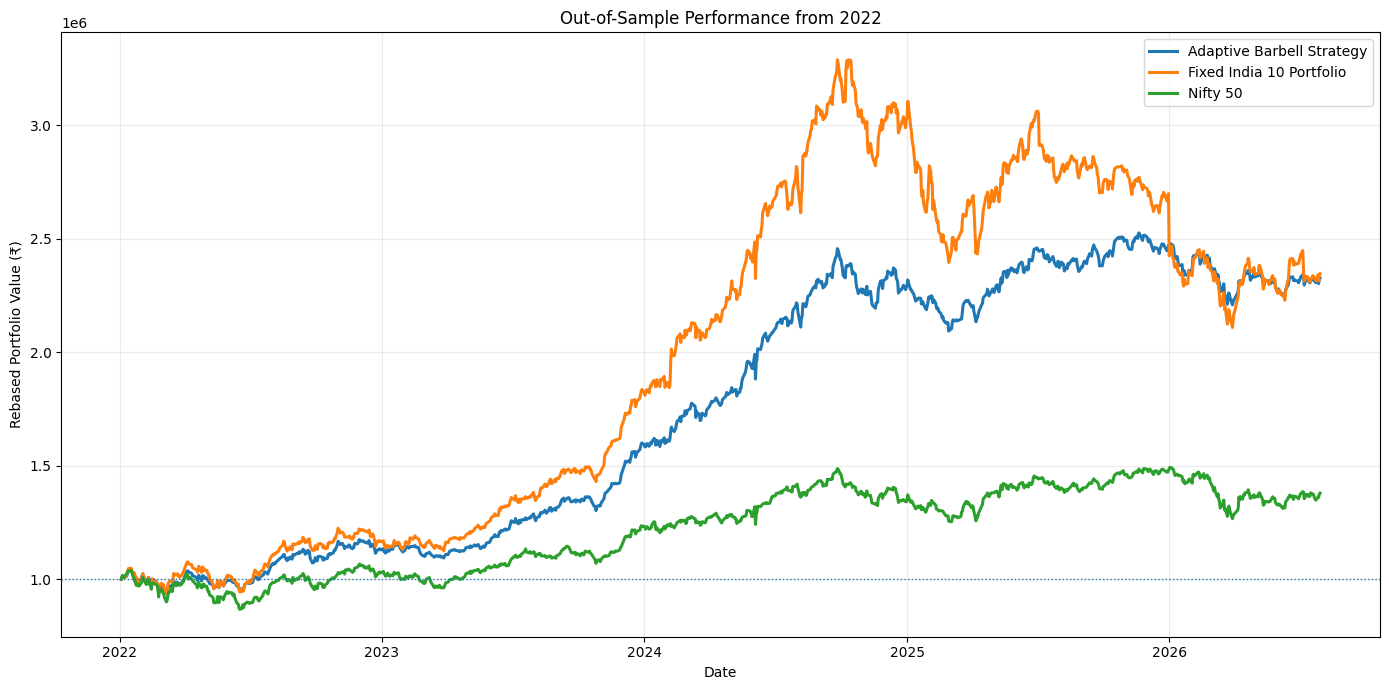

In [14]:
out_of_sample_values = (
    out_of_sample_evaluation["Values"]
)

plt.figure(figsize=(14, 7))

for column in out_of_sample_values.columns:

    plt.plot(
        out_of_sample_values.index,
        out_of_sample_values[column],
        linewidth=2.2,
        label=column,
    )

plt.axhline(
    INITIAL_CAPITAL,
    linewidth=1,
    linestyle=":",
)

plt.title(
    "Out-of-Sample Performance from 2022"
)
plt.xlabel("Date")
plt.ylabel("Rebased Portfolio Value (₹)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Development and Out-of-Sample Interpretation

### Development-period result

During the development period, the Adaptive Barbell strategy generated a CAGR of 19.70%, equal to the fixed portfolio's CAGR.

However, the Adaptive strategy reduced annualised volatility from 17.31% to 14.90% and improved maximum drawdown from -32.06% to -23.73%.

Its Sharpe, Sortino and Calmar ratios were also higher, indicating improved risk-adjusted performance.

### Out-of-sample result

From 2022 onward, the Adaptive strategy generated a CAGR of 20.31%, compared with 20.52% for the fixed India 10 portfolio.

The strategy therefore sacrificed only 0.21 percentage points of annual return while producing substantially lower risk.

Annualised volatility declined from 18.92% to 12.91%, while maximum drawdown improved from -35.86% to -14.79%.

The Adaptive strategy also generated:

- a Sharpe ratio of 1.03 versus 0.77,
- a Sortino ratio of 1.50 versus 1.06,
- a Calmar ratio of 1.37 versus 0.57, and
- a beta of 0.81 versus 1.00.

### Preliminary robustness conclusion

The strategy's risk-adjusted advantage persisted during the out-of-sample period.

The strongest evidence relates to downside protection rather than absolute-return enhancement. The strategy maintained nearly the same CAGR as the fixed portfolio while materially reducing volatility, market sensitivity and maximum drawdown.

The strategy is therefore provisionally classified as **moderately robust**, subject to parameter-sensitivity and transaction-cost stress testing.

### Important limitation

The test is out-of-sample with respect to time and the frozen strategy parameters. It is not completely free from selection bias because the current ten-stock portfolio was chosen using present-day information.

## 7. Parameter-Sensitivity Testing

The strategy is tested across reasonable alternative values for:

- momentum lookback,
- volatility lookback,
- market-trend lookback, and
- defensive equity exposure.

The objective is not to discover the historically best combination. A robust strategy should perform reasonably across many nearby parameter combinations rather than depending on one exact setting.

In [15]:
# ---------------------------------------------------------
# Parameter grid
# ---------------------------------------------------------

momentum_lookbacks = [63, 126, 252]
volatility_lookbacks = [21, 63, 126]
trend_lookbacks = [100, 150, 200]
defensive_exposures = [0.50, 0.70, 0.80]

parameter_combinations = list(
    product(
        momentum_lookbacks,
        volatility_lookbacks,
        trend_lookbacks,
        defensive_exposures,
    )
)

print(f"Parameter combinations to test: {len(parameter_combinations)}")

Parameter combinations to test: 81


In [16]:
# ---------------------------------------------------------
# Run every parameter combination
# ---------------------------------------------------------

sensitivity_records = []
failed_combinations = []

for combination_number, (
    momentum_window,
    volatility_window,
    trend_window,
    defensive_exposure,
) in enumerate(parameter_combinations, start=1):

    try:
        test_backtest = run_adaptive_barbell_backtest(
            stock_price_data=stock_prices,
            benchmark_price_data=benchmark_prices[BENCHMARK_NAME],
            resilient_stock_tickers=resilient_tickers,
            growth_stock_tickers=growth_tickers,
            momentum_lookback=momentum_window,
            volatility_lookback=volatility_window,
            trend_lookback=trend_window,
            defensive_equity_exposure=defensive_exposure,
            transaction_cost_rate=TRANSACTION_COST_RATE,
            initial_capital=INITIAL_CAPITAL,
            annual_cash_rate=RISK_FREE_RATE,
            trading_days=TRADING_DAYS,
        )

        strategy_values = (
            test_backtest["Strategy Values"]
            .loc[
                test_backtest["Strategy Values"].index
                >= OUT_OF_SAMPLE_START_DATE
            ]
            .dropna()
        )

        benchmark_period_prices = (
            benchmark_prices[BENCHMARK_NAME]
            .reindex(strategy_values.index)
            .dropna()
        )

        strategy_values = strategy_values.reindex(
            benchmark_period_prices.index
        )

        benchmark_period_returns = (
            benchmark_period_prices
            .pct_change()
            .dropna()
        )

        strategy_metrics = calculate_period_metrics(
            value_series=strategy_values,
            benchmark_return_series=benchmark_period_returns,
            annual_risk_free_rate=RISK_FREE_RATE,
            trading_days=TRADING_DAYS,
        )

        sensitivity_records.append(
            {
                "Momentum Lookback": momentum_window,
                "Volatility Lookback": volatility_window,
                "Trend Lookback": trend_window,
                "Defensive Exposure": defensive_exposure,
                "CAGR": strategy_metrics["CAGR"],
                "Annualised Volatility": strategy_metrics[
                    "Annualised Volatility"
                ],
                "Sharpe Ratio": strategy_metrics["Sharpe Ratio"],
                "Sortino Ratio": strategy_metrics["Sortino Ratio"],
                "Maximum Drawdown": strategy_metrics[
                    "Maximum Drawdown"
                ],
                "Calmar Ratio": strategy_metrics["Calmar Ratio"],
                "Beta vs Nifty 50": strategy_metrics[
                    "Beta vs Nifty 50"
                ],
                "Average Turnover": test_backtest[
                    "Turnover"
                ].mean(),
                "Total Transaction Costs": test_backtest[
                    "Transaction Costs"
                ].sum(),
            }
        )

    except Exception as error:
        failed_combinations.append(
            {
                "Momentum Lookback": momentum_window,
                "Volatility Lookback": volatility_window,
                "Trend Lookback": trend_window,
                "Defensive Exposure": defensive_exposure,
                "Error": str(error),
            }
        )

    if combination_number % 10 == 0:
        print(
            f"Completed {combination_number} "
            f"of {len(parameter_combinations)} combinations."
        )


sensitivity_results = pd.DataFrame(
    sensitivity_records
)

failed_sensitivity_tests = pd.DataFrame(
    failed_combinations
)

assert not sensitivity_results.empty, \
    "No sensitivity-test results were generated."

print("\nParameter-sensitivity testing completed.")
print("-" * 60)
print(f"Successful tests: {len(sensitivity_results)}")
print(f"Failed tests: {len(failed_sensitivity_tests)}")

Completed 10 of 81 combinations.
Completed 20 of 81 combinations.
Completed 30 of 81 combinations.
Completed 40 of 81 combinations.
Completed 50 of 81 combinations.
Completed 60 of 81 combinations.
Completed 70 of 81 combinations.
Completed 80 of 81 combinations.

Parameter-sensitivity testing completed.
------------------------------------------------------------
Successful tests: 81
Failed tests: 0


In [17]:
# ---------------------------------------------------------
# Compare parameter combinations with the fixed portfolio
# ---------------------------------------------------------

fixed_oos_cagr = out_of_sample_metrics.loc[
    "CAGR",
    "Fixed India 10 Portfolio",
]

fixed_oos_sharpe = out_of_sample_metrics.loc[
    "Sharpe Ratio",
    "Fixed India 10 Portfolio",
]

fixed_oos_drawdown = out_of_sample_metrics.loc[
    "Maximum Drawdown",
    "Fixed India 10 Portfolio",
]

sensitivity_results["CAGR Difference vs Fixed"] = (
    sensitivity_results["CAGR"]
    - fixed_oos_cagr
)

sensitivity_results["Sharpe Difference vs Fixed"] = (
    sensitivity_results["Sharpe Ratio"]
    - fixed_oos_sharpe
)

sensitivity_results["Drawdown Improvement vs Fixed"] = (
    sensitivity_results["Maximum Drawdown"]
    - fixed_oos_drawdown
)

robustness_summary = pd.Series(
    {
        "Median CAGR": sensitivity_results["CAGR"].median(),
        "Minimum CAGR": sensitivity_results["CAGR"].min(),
        "Maximum CAGR": sensitivity_results["CAGR"].max(),
        "Median Volatility": sensitivity_results[
            "Annualised Volatility"
        ].median(),
        "Median Sharpe Ratio": sensitivity_results[
            "Sharpe Ratio"
        ].median(),
        "Minimum Sharpe Ratio": sensitivity_results[
            "Sharpe Ratio"
        ].min(),
        "Median Maximum Drawdown": sensitivity_results[
            "Maximum Drawdown"
        ].median(),
        "Combinations Beating Fixed Sharpe": (
            sensitivity_results["Sharpe Ratio"]
            > fixed_oos_sharpe
        ).mean(),
        "Combinations Improving Fixed Drawdown": (
            sensitivity_results["Maximum Drawdown"]
            > fixed_oos_drawdown
        ).mean(),
        "Combinations Within 2% CAGR of Fixed": (
            sensitivity_results["CAGR Difference vs Fixed"]
            >= -0.02
        ).mean(),
    }
)

display(
    robustness_summary.to_frame("Result").style.format(
        {
            "Result": "{:.2%}",
        }
    )
)

,Result
Median CAGR,20.03%
Minimum CAGR,19.33%
Maximum CAGR,20.68%
Median Volatility,12.83%
Median Sharpe Ratio,103.27%
Minimum Sharpe Ratio,95.61%
Median Maximum Drawdown,-14.80%
Combinations Beating Fixed Sharpe,100.00%
Combinations Improving Fixed Drawdown,100.00%
Combinations Within 2% CAGR of Fixed,100.00%


In [18]:
# Correctly format percentages and ratios separately

corrected_robustness_summary = pd.DataFrame(
    {
        "Metric": [
            "Median CAGR",
            "Minimum CAGR",
            "Maximum CAGR",
            "Median Volatility",
            "Median Sharpe Ratio",
            "Minimum Sharpe Ratio",
            "Median Maximum Drawdown",
            "Combinations Beating Fixed Sharpe",
            "Combinations Improving Fixed Drawdown",
            "Combinations Within 2% CAGR of Fixed",
        ],
        "Result": [
            f"{sensitivity_results['CAGR'].median():.2%}",
            f"{sensitivity_results['CAGR'].min():.2%}",
            f"{sensitivity_results['CAGR'].max():.2%}",
            f"{sensitivity_results['Annualised Volatility'].median():.2%}",
            f"{sensitivity_results['Sharpe Ratio'].median():.2f}",
            f"{sensitivity_results['Sharpe Ratio'].min():.2f}",
            f"{sensitivity_results['Maximum Drawdown'].median():.2%}",
            f"{(sensitivity_results['Sharpe Ratio'] > fixed_oos_sharpe).mean():.2%}",
            f"{(sensitivity_results['Maximum Drawdown'] > fixed_oos_drawdown).mean():.2%}",
            f"{(sensitivity_results['CAGR Difference vs Fixed'] >= -0.02).mean():.2%}",
        ],
    }
).set_index("Metric")

print("Corrected Parameter-Sensitivity Summary")
display(corrected_robustness_summary)

Corrected Parameter-Sensitivity Summary


,Result
Metric,
Median CAGR,20.03%
Minimum CAGR,19.33%
Maximum CAGR,20.68%
Median Volatility,12.83%
Median Sharpe Ratio,1.03
Minimum Sharpe Ratio,0.96
Median Maximum Drawdown,-14.80%
Combinations Beating Fixed Sharpe,100.00%
Combinations Improving Fixed Drawdown,100.00%


## 8. Parameter-Sensitivity Interpretation

A total of 81 alternative parameter combinations were evaluated during the out-of-sample period.

The tested combinations varied:

- momentum lookback,
- volatility lookback,
- market-trend lookback, and
- defensive equity exposure.

### Stability of returns

The median CAGR across all combinations was 20.03%.

The minimum CAGR was 19.33% and the maximum CAGR was 20.68%, representing a relatively narrow performance range.

All tested combinations remained within two percentage points of the fixed portfolio's CAGR.

### Stability of risk-adjusted performance

The median Sharpe ratio was 1.03, while the weakest tested Sharpe ratio was approximately 0.96.

Every tested parameter combination produced a higher Sharpe ratio than the fixed India 10 portfolio.

### Stability of downside protection

The median maximum drawdown was -14.80%.

Every tested parameter combination produced a smaller maximum drawdown than the fixed portfolio.

### Preliminary parameter-robustness conclusion

The strategy does not appear to depend on one precise combination of momentum, volatility, trend or defensive-exposure assumptions.

Reasonable variations in the parameters produced similar returns, consistently stronger risk-adjusted performance and materially improved downside protection.

The strategy is therefore classified as **robust across the tested parameter grid**.

However, this conclusion applies to the strategy parameters only. The portfolio's fixed ten-stock universe remains subject to selection and survivorship bias.

## 9. Transaction-Cost Stress Testing

The Adaptive Barbell strategy is tested under progressively higher transaction-cost assumptions.

The objective is to determine whether its out-of-sample performance depends on unrealistically low trading costs.

The tested one-way turnover costs are:

- 0.00%
- 0.10%
- 0.15%
- 0.25%
- 0.50%

In [19]:
# ---------------------------------------------------------
# Transaction-cost assumptions
# ---------------------------------------------------------

transaction_cost_scenarios = [
    0.0000,
    0.0010,
    0.0015,
    0.0025,
    0.0050,
]

transaction_cost_records = []

for cost_rate in transaction_cost_scenarios:

    cost_test = run_adaptive_barbell_backtest(
        stock_price_data=stock_prices,
        benchmark_price_data=benchmark_prices[BENCHMARK_NAME],
        resilient_stock_tickers=resilient_tickers,
        growth_stock_tickers=growth_tickers,
        momentum_lookback=BASE_MOMENTUM_LOOKBACK,
        volatility_lookback=BASE_VOLATILITY_LOOKBACK,
        trend_lookback=BASE_TREND_LOOKBACK,
        defensive_equity_exposure=BASE_DEFENSIVE_EQUITY_EXPOSURE,
        transaction_cost_rate=cost_rate,
        initial_capital=INITIAL_CAPITAL,
        annual_cash_rate=RISK_FREE_RATE,
        trading_days=TRADING_DAYS,
    )

    # Keep only the out-of-sample period
    strategy_values_oos = (
        cost_test["Strategy Values"]
        .loc[
            cost_test["Strategy Values"].index
            >= OUT_OF_SAMPLE_START_DATE
        ]
        .dropna()
    )

    # Rebase every scenario to ₹10 lakh on the same basis
    strategy_values_oos = (
        strategy_values_oos
        .div(strategy_values_oos.iloc[0])
        .mul(INITIAL_CAPITAL)
    )

    benchmark_period_prices = (
        benchmark_prices[BENCHMARK_NAME]
        .reindex(strategy_values_oos.index)
        .dropna()
    )

    strategy_values_oos = (
        strategy_values_oos
        .reindex(benchmark_period_prices.index)
        .dropna()
    )

    benchmark_period_returns = (
        benchmark_period_prices
        .pct_change()
        .dropna()
    )

    metrics = calculate_period_metrics(
        value_series=strategy_values_oos,
        benchmark_return_series=benchmark_period_returns,
        annual_risk_free_rate=RISK_FREE_RATE,
        trading_days=TRADING_DAYS,
    )

    out_of_sample_costs = (
        cost_test["Transaction Costs"]
        .loc[
            cost_test["Transaction Costs"].index
            >= OUT_OF_SAMPLE_START_DATE
        ]
        .sum()
    )

    out_of_sample_turnover = (
        cost_test["Turnover"]
        .loc[
            cost_test["Turnover"].index
            >= OUT_OF_SAMPLE_START_DATE
        ]
    )

    transaction_cost_records.append(
        {
            "Transaction Cost Rate": cost_rate,
            "Ending Value (₹)": strategy_values_oos.iloc[-1],
            "CAGR": metrics["CAGR"],
            "Annualised Volatility": metrics[
                "Annualised Volatility"
            ],
            "Sharpe Ratio": metrics["Sharpe Ratio"],
            "Maximum Drawdown": metrics[
                "Maximum Drawdown"
            ],
            "Calmar Ratio": metrics["Calmar Ratio"],
            "Average Turnover": out_of_sample_turnover.mean(),
            "Estimated OOS Trading Costs (₹)": out_of_sample_costs,
        }
    )

transaction_cost_results = pd.DataFrame(
    transaction_cost_records
).sort_values(
    "Transaction Cost Rate"
).reset_index(drop=True)

# Measure performance deterioration relative to the zero-cost case
zero_cost_cagr = transaction_cost_results.loc[
    transaction_cost_results[
        "Transaction Cost Rate"
    ] == 0,
    "CAGR",
].iloc[0]

transaction_cost_results["CAGR Drag vs Zero Cost"] = (
    transaction_cost_results["CAGR"]
    - zero_cost_cagr
)

print("Transaction-cost stress testing completed.")
display(transaction_cost_results)

Transaction-cost stress testing completed.


,Transaction Cost Rate,Ending Value (₹),CAGR,Annualised Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Average Turnover,Estimated OOS Trading Costs (₹),CAGR Drag vs Zero Cost
0,0.0000,"2,346,805.6452",0.2052,0.1291,1.0481,-0.1472,1.3940,0.0994,0.0000,0.0000
1,0.0010,"2,334,153.1309",0.2038,0.1291,1.0388,-0.1477,1.3803,0.0994,"22,714.3909",-0.0014
2,0.0015,"2,327,851.5999",0.2031,0.1291,1.0342,-0.1479,1.3735,0.0994,"33,884.6009",-0.0021
3,0.0025,"2,315,297.7832",0.2017,0.1291,1.0249,-0.1483,1.3600,0.0994,"55,856.1460",-0.0036
4,0.0050,"2,284,198.5823",0.1981,0.1291,1.0017,-0.1494,1.3265,0.0994,"108,679.9436",-0.0071


In [20]:
formatted_cost_results = (
    transaction_cost_results
    .copy()
    .astype(object)
)

for row_index in formatted_cost_results.index:

    formatted_cost_results.loc[
        row_index,
        "Transaction Cost Rate",
    ] = (
        f"{transaction_cost_results.loc[row_index, 'Transaction Cost Rate']:.2%}"
    )

    formatted_cost_results.loc[
        row_index,
        "Ending Value (₹)",
    ] = (
        f"₹{transaction_cost_results.loc[row_index, 'Ending Value (₹)']:,.0f}"
    )

    for metric in [
        "CAGR",
        "Annualised Volatility",
        "Maximum Drawdown",
        "Average Turnover",
        "CAGR Drag vs Zero Cost",
    ]:
        formatted_cost_results.loc[
            row_index,
            metric,
        ] = (
            f"{transaction_cost_results.loc[row_index, metric]:.2%}"
        )

    for metric in [
        "Sharpe Ratio",
        "Calmar Ratio",
    ]:
        formatted_cost_results.loc[
            row_index,
            metric,
        ] = (
            f"{transaction_cost_results.loc[row_index, metric]:.2f}"
        )

    formatted_cost_results.loc[
        row_index,
        "Estimated OOS Trading Costs (₹)",
    ] = (
        f"₹{transaction_cost_results.loc[row_index, 'Estimated OOS Trading Costs (₹)']:,.0f}"
    )

print("Out-of-Sample Transaction-Cost Stress Test")
display(formatted_cost_results)

Out-of-Sample Transaction-Cost Stress Test


,Transaction Cost Rate,Ending Value (₹),CAGR,Annualised Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,Average Turnover,Estimated OOS Trading Costs (₹),CAGR Drag vs Zero Cost
0,0.00%,"₹2,346,806",20.52%,12.91%,1.05,-14.72%,1.39,9.94%,₹0,0.00%
1,0.10%,"₹2,334,153",20.38%,12.91%,1.04,-14.77%,1.38,9.94%,"₹22,714",-0.14%
2,0.15%,"₹2,327,852",20.31%,12.91%,1.03,-14.79%,1.37,9.94%,"₹33,885",-0.21%
3,0.25%,"₹2,315,298",20.17%,12.91%,1.02,-14.83%,1.36,9.94%,"₹55,856",-0.36%
4,0.50%,"₹2,284,199",19.81%,12.91%,1.00,-14.94%,1.33,9.94%,"₹108,680",-0.71%


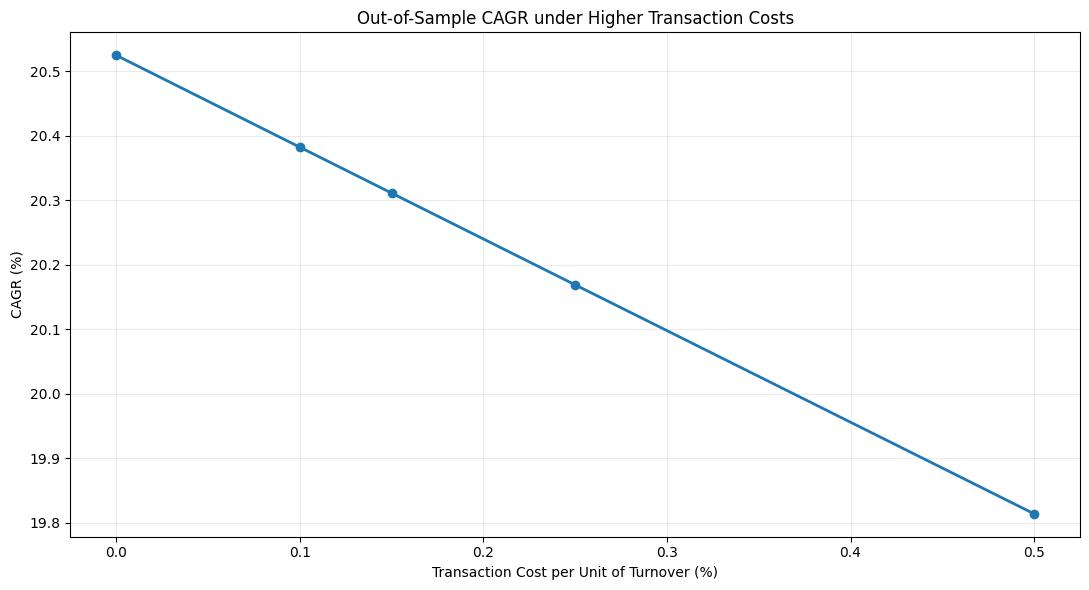

In [21]:
plt.figure(figsize=(11, 6))

plt.plot(
    transaction_cost_results["Transaction Cost Rate"] * 100,
    transaction_cost_results["CAGR"] * 100,
    marker="o",
    linewidth=2,
)

plt.title("Out-of-Sample CAGR under Higher Transaction Costs")
plt.xlabel("Transaction Cost per Unit of Turnover (%)")
plt.ylabel("CAGR (%)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Transaction-Cost Stress-Test Interpretation

The Adaptive Barbell strategy was evaluated using transaction-cost assumptions ranging from 0.00% to 0.50% per unit of one-way portfolio turnover.

### Base-case cost assumption

At the base transaction-cost assumption of 0.15%, the strategy generated:

- CAGR of 20.31%,
- Sharpe ratio of 1.03,
- maximum drawdown of -14.79%, and
- estimated out-of-sample trading costs of approximately ₹33,885.

The CAGR reduction relative to the zero-cost scenario was only 0.21 percentage points.

### High-cost stress scenario

At the highest tested transaction-cost assumption of 0.50%, the strategy still generated:

- CAGR of 19.81%,
- Sharpe ratio of 1.00,
- maximum drawdown of -14.94%, and
- Calmar ratio of 1.33.

The CAGR reduction relative to the zero-cost scenario was 0.71 percentage points.

### Role of portfolio turnover

Average one-way turnover was approximately 9.94% per monthly rebalance.

The relatively controlled turnover limited the effect of higher trading-cost assumptions on overall strategy performance.

### Preliminary conclusion

The Adaptive Barbell strategy remained economically viable across all tested transaction-cost assumptions.

Its return and risk-adjusted performance deteriorated gradually rather than collapsing as costs increased. This indicates that the preliminary results are not dependent on assuming negligible trading costs.

The strategy is therefore classified as **robust to the tested range of transaction-cost assumptions**.

Detailed Indian brokerage charges, securities transaction tax, exchange charges, GST, stamp duty and taxation remain to be modelled in a later version.

## 11. Rolling One-Year Performance Analysis

Full-period statistics can hide major changes in performance.

This section calculates rolling one-year measures for the Adaptive strategy, fixed India 10 portfolio and Nifty 50:

- rolling return,
- annualised volatility,
- Sharpe ratio,
- beta, and
- maximum drawdown.

A 252-trading-day window is used as an approximation of one market year.

In [23]:
# ---------------------------------------------------------
# Rolling one-year assumptions
# ---------------------------------------------------------

ROLLING_WINDOW = 252

rolling_returns_input = (
    full_comparison_values
    .pct_change()
)

daily_risk_free_rate = (
    (1 + RISK_FREE_RATE)
    ** (1 / TRADING_DAYS)
    - 1
)


def rolling_maximum_drawdown(values):
    """
    Calculate maximum drawdown inside one rolling window.
    """

    values = np.asarray(values, dtype=float)

    running_peak = np.maximum.accumulate(values)

    drawdowns = (
        values / running_peak - 1
    )

    return drawdowns.min()


rolling_metric_records = {}

for investment_name in full_comparison_values.columns:

    value_series = (
        full_comparison_values[investment_name]
        .astype(float)
    )

    return_series = (
        rolling_returns_input[investment_name]
        .astype(float)
    )

    rolling_total_return = (
        value_series
        .div(value_series.shift(ROLLING_WINDOW))
        .sub(1)
    )

    rolling_volatility = (
        return_series
        .rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        )
        .std(ddof=1)
        .mul(np.sqrt(TRADING_DAYS))
    )

    rolling_excess_return = (
        return_series
        - daily_risk_free_rate
    )

    rolling_sharpe = (
        rolling_excess_return
        .rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        )
        .mean()
        .mul(TRADING_DAYS)
        .div(rolling_volatility)
    )

    rolling_drawdown = (
        value_series
        .rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        )
        .apply(
            rolling_maximum_drawdown,
            raw=True,
        )
    )

    rolling_metric_records[investment_name] = {
        "Rolling Return": rolling_total_return,
        "Rolling Volatility": rolling_volatility,
        "Rolling Sharpe": rolling_sharpe,
        "Rolling Maximum Drawdown": rolling_drawdown,
    }


# ---------------------------------------------------------
# Rolling beta against Nifty 50
# ---------------------------------------------------------

benchmark_daily_returns = (
    rolling_returns_input[BENCHMARK_NAME]
)

rolling_betas = {}

benchmark_rolling_variance = (
    benchmark_daily_returns
    .rolling(
        ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW,
    )
    .var(ddof=1)
)

for investment_name in full_comparison_values.columns:

    investment_returns = (
        rolling_returns_input[investment_name]
    )

    rolling_covariance = (
        investment_returns
        .rolling(
            ROLLING_WINDOW,
            min_periods=ROLLING_WINDOW,
        )
        .cov(benchmark_daily_returns)
    )

    rolling_betas[investment_name] = (
        rolling_covariance
        / benchmark_rolling_variance
    )


# ---------------------------------------------------------
# Combine rolling results
# ---------------------------------------------------------

rolling_return_table = pd.DataFrame(
    {
        name: metrics["Rolling Return"]
        for name, metrics in rolling_metric_records.items()
    }
)

rolling_volatility_table = pd.DataFrame(
    {
        name: metrics["Rolling Volatility"]
        for name, metrics in rolling_metric_records.items()
    }
)

rolling_sharpe_table = pd.DataFrame(
    {
        name: metrics["Rolling Sharpe"]
        for name, metrics in rolling_metric_records.items()
    }
)

rolling_drawdown_table = pd.DataFrame(
    {
        name: metrics["Rolling Maximum Drawdown"]
        for name, metrics in rolling_metric_records.items()
    }
)

rolling_beta_table = pd.DataFrame(
    rolling_betas
)

print("Rolling one-year metrics calculated successfully.")
print("-" * 60)
print(
    "First available rolling date:",
    rolling_sharpe_table.dropna().index.min().date(),
)
print(
    "Latest available rolling date:",
    rolling_sharpe_table.dropna().index.max().date(),
)

Rolling one-year metrics calculated successfully.
------------------------------------------------------------
First available rolling date: 2017-11-03
Latest available rolling date: 2026-07-30


In [24]:
# ---------------------------------------------------------
# Evaluate rolling consistency during the out-of-sample period
# ---------------------------------------------------------

oos_rolling_sharpe = (
    rolling_sharpe_table
    .loc[
        rolling_sharpe_table.index
        >= OUT_OF_SAMPLE_START_DATE
    ]
    .dropna()
)

oos_rolling_volatility = (
    rolling_volatility_table
    .loc[
        rolling_volatility_table.index
        >= OUT_OF_SAMPLE_START_DATE
    ]
    .dropna()
)

oos_rolling_drawdown = (
    rolling_drawdown_table
    .loc[
        rolling_drawdown_table.index
        >= OUT_OF_SAMPLE_START_DATE
    ]
    .dropna()
)

oos_rolling_beta = (
    rolling_beta_table
    .loc[
        rolling_beta_table.index
        >= OUT_OF_SAMPLE_START_DATE
    ]
    .dropna()
)

adaptive_name = "Adaptive Barbell Strategy"
fixed_name = "Fixed India 10 Portfolio"

rolling_consistency_summary = pd.Series(
    {
        "Median Adaptive Rolling Sharpe":
            oos_rolling_sharpe[adaptive_name].median(),

        "Median Fixed Rolling Sharpe":
            oos_rolling_sharpe[fixed_name].median(),

        "Periods Adaptive Sharpe Above Fixed":
            (
                oos_rolling_sharpe[adaptive_name]
                > oos_rolling_sharpe[fixed_name]
            ).mean(),

        "Periods Adaptive Volatility Below Fixed":
            (
                oos_rolling_volatility[adaptive_name]
                < oos_rolling_volatility[fixed_name]
            ).mean(),

        "Periods Adaptive Drawdown Better Than Fixed":
            (
                oos_rolling_drawdown[adaptive_name]
                > oos_rolling_drawdown[fixed_name]
            ).mean(),

        "Median Adaptive Rolling Beta":
            oos_rolling_beta[adaptive_name].median(),

        "Median Fixed Rolling Beta":
            oos_rolling_beta[fixed_name].median(),
    }
)

corrected_rolling_summary = pd.DataFrame(
    {
        "Metric": [
            "Median Adaptive Rolling Sharpe",
            "Median Fixed Rolling Sharpe",
            "Periods Adaptive Sharpe Above Fixed",
            "Periods Adaptive Volatility Below Fixed",
            "Periods Adaptive Drawdown Better Than Fixed",
            "Median Adaptive Rolling Beta",
            "Median Fixed Rolling Beta",
        ],
        "Result": [
            f"{rolling_consistency_summary['Median Adaptive Rolling Sharpe']:.2f}",
            f"{rolling_consistency_summary['Median Fixed Rolling Sharpe']:.2f}",
            f"{rolling_consistency_summary['Periods Adaptive Sharpe Above Fixed']:.2%}",
            f"{rolling_consistency_summary['Periods Adaptive Volatility Below Fixed']:.2%}",
            f"{rolling_consistency_summary['Periods Adaptive Drawdown Better Than Fixed']:.2%}",
            f"{rolling_consistency_summary['Median Adaptive Rolling Beta']:.2f}",
            f"{rolling_consistency_summary['Median Fixed Rolling Beta']:.2f}",
        ],
    }
).set_index("Metric")

print("Out-of-Sample Rolling Consistency Summary")
display(corrected_rolling_summary)

Out-of-Sample Rolling Consistency Summary


,Result
Metric,
Median Adaptive Rolling Sharpe,0.99
Median Fixed Rolling Sharpe,0.89
Periods Adaptive Sharpe Above Fixed,47.66%
Periods Adaptive Volatility Below Fixed,98.41%
Periods Adaptive Drawdown Better Than Fixed,89.14%
Median Adaptive Rolling Beta,0.80
Median Fixed Rolling Beta,0.92


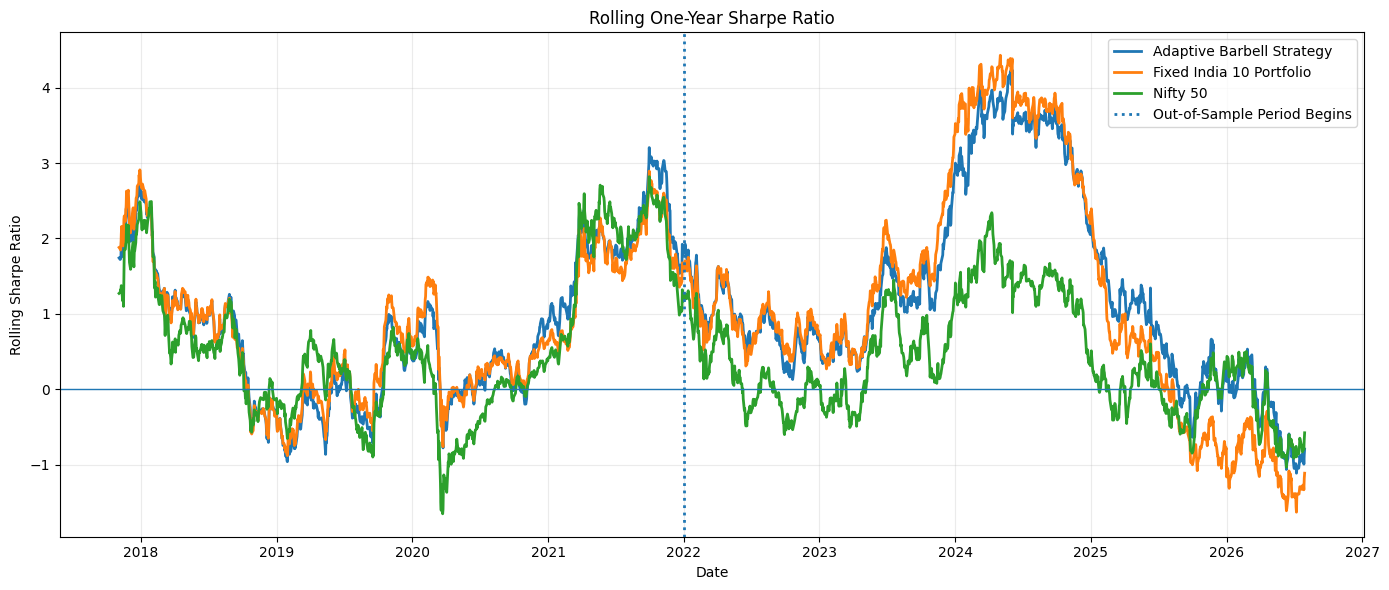

In [25]:
plt.figure(figsize=(14, 6))

for column in rolling_sharpe_table.columns:

    plt.plot(
        rolling_sharpe_table.index,
        rolling_sharpe_table[column],
        linewidth=2,
        label=column,
    )

plt.axhline(
    0,
    linewidth=1,
)

plt.axvline(
    OUT_OF_SAMPLE_START_DATE,
    linewidth=2,
    linestyle=":",
    label="Out-of-Sample Period Begins",
)

plt.title("Rolling One-Year Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 12. Rolling-Performance Interpretation

Rolling one-year analysis provides a more demanding test than full-period performance because it evaluates the strategy across many overlapping market periods.

### Risk consistency

The Adaptive Barbell strategy generated lower annualised volatility than the fixed India 10 portfolio during 98.41% of out-of-sample rolling periods.

It also produced a better rolling maximum drawdown during 89.14% of the evaluated periods.

These results indicate that the strategy's risk-reduction benefit was highly consistent through time rather than being caused by one isolated market event.

### Market sensitivity

The median rolling beta of the Adaptive strategy was 0.80, compared with 0.92 for the fixed portfolio.

This supports the conclusion that the market-regime overlay and defensive cash allocation consistently reduced exposure to broad-market movements.

### Rolling risk-adjusted performance

The Adaptive strategy generated a median rolling Sharpe ratio of 0.99, compared with 0.89 for the fixed portfolio.

However, the Adaptive strategy's rolling Sharpe ratio exceeded the fixed portfolio in only 47.66% of out-of-sample periods.

This means that the strategy did not produce superior risk-adjusted performance in every one-year window. Its higher median Sharpe was influenced by stronger performance during particular periods, especially periods in which downside protection was valuable.

### Rolling-performance conclusion

The strongest and most persistent evidence in favour of the Adaptive Barbell strategy relates to:

- lower volatility,
- smaller drawdowns,
- lower market beta, and
- more stable downside behaviour.

The evidence for consistently higher rolling Sharpe ratios is mixed.

The strategy should therefore be described primarily as a **risk-managed allocation strategy**, rather than as a strategy that consistently maximises short-term risk-adjusted returns.

## 13. Market-Regime Performance Analysis

The Adaptive Barbell strategy operates under two market regimes:

- **Normal regime:** 100% equity exposure
- **Defensive regime:** 70% equity exposure and 30% cash

This section evaluates the Adaptive strategy, fixed India 10 portfolio and Nifty 50 separately during each regime.

The purpose is to determine whether the defensive overlay reduced risk when it was activated and whether the cost of protection was reasonable.

In [26]:
# ---------------------------------------------------------
# Create a daily market-regime series
# ---------------------------------------------------------

execution_schedule = (
    base_backtest["Execution Schedule"]
    .copy()
)

daily_regime = (
    execution_schedule["Market Regime"]
    .reindex(full_comparison_values.index)
    .ffill()
    .rename("Market Regime")
)

# The first observation may occur before the first executed signal
regime_analysis_data = pd.concat(
    [
        full_comparison_values.pct_change(),
        daily_regime,
    ],
    axis=1,
).dropna()

assert not regime_analysis_data.empty
assert set(
    regime_analysis_data["Market Regime"].unique()
).issubset({"Normal", "Defensive"})

print("Daily regime history created successfully.")
print("-" * 55)
print(
    regime_analysis_data["Market Regime"]
    .value_counts()
    .to_frame("Trading Days")
)

Daily regime history created successfully.
-------------------------------------------------------
               Trading Days
Market Regime              
Normal                 1863
Defensive               549


In [27]:
def calculate_regime_metrics(
    return_series,
    annual_risk_free_rate=0.065,
    trading_days=252,
):
    """
    Calculate annualised metrics using only returns observed
    within a particular market regime.
    """

    return_series = (
        return_series
        .dropna()
        .astype(float)
    )

    observations = len(return_series)

    if observations < 2:
        return {
            "Trading Days": observations,
            "Cumulative Return": np.nan,
            "Annualised Return": np.nan,
            "Annualised Volatility": np.nan,
            "Sharpe Ratio": np.nan,
            "Maximum Drawdown": np.nan,
            "Positive-Day Frequency": np.nan,
        }

    cumulative_return = (
        (1 + return_series).prod() - 1
    )

    annualised_return = (
        (1 + cumulative_return)
        ** (trading_days / observations)
        - 1
    )

    annualised_volatility = (
        return_series.std(ddof=1)
        * np.sqrt(trading_days)
    )

    daily_risk_free_rate = (
        (1 + annual_risk_free_rate)
        ** (1 / trading_days)
        - 1
    )

    annualised_excess_return = (
        (return_series - daily_risk_free_rate)
        .mean()
        * trading_days
    )

    sharpe_ratio = (
        annualised_excess_return
        / annualised_volatility
        if annualised_volatility > 0
        else np.nan
    )

    # Construct a wealth path using only the selected regime days
    regime_wealth = (
        (1 + return_series)
        .cumprod()
    )

    regime_drawdown = (
        regime_wealth
        / regime_wealth.cummax()
        - 1
    )

    maximum_drawdown = (
        regime_drawdown.min()
    )

    positive_day_frequency = (
        (return_series > 0).mean()
    )

    return {
        "Trading Days": observations,
        "Cumulative Return": cumulative_return,
        "Annualised Return": annualised_return,
        "Annualised Volatility": annualised_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Positive-Day Frequency": positive_day_frequency,
    }

In [28]:
regime_metric_records = []

for market_regime in ["Normal", "Defensive"]:

    regime_subset = (
        regime_analysis_data.loc[
            regime_analysis_data["Market Regime"]
            == market_regime
        ]
    )

    for investment_name in full_comparison_values.columns:

        metrics = calculate_regime_metrics(
            return_series=regime_subset[
                investment_name
            ],
            annual_risk_free_rate=RISK_FREE_RATE,
            trading_days=TRADING_DAYS,
        )

        regime_metric_records.append(
            {
                "Market Regime": market_regime,
                "Investment": investment_name,
                **metrics,
            }
        )

regime_performance = pd.DataFrame(
    regime_metric_records
)

assert not regime_performance.empty

print("Market-regime performance calculated successfully.")
display(regime_performance)

Market-regime performance calculated successfully.


,Market Regime,Investment,Trading Days,Cumulative Return,Annualised Return,Annualised Volatility,Sharpe Ratio,Maximum Drawdown,Positive-Day Frequency
0,Normal,Adaptive Barbell Strategy,1863,3.2012,0.2143,0.1367,1.0282,-0.1615,0.5561
1,Normal,Fixed India 10 Portfolio,1863,3.5201,0.2264,0.1568,0.9787,-0.2519,0.5486
2,Normal,Nifty 50,1863,1.0515,0.1021,0.1318,0.3257,-0.1989,0.5411
3,Defensive,Adaptive Barbell Strategy,549,0.4173,0.1736,0.1506,0.7206,-0.1936,0.5556
4,Defensive,Fixed India 10 Portfolio,549,0.3243,0.1376,0.2452,0.3929,-0.2876,0.5355
5,Defensive,Nifty 50,549,0.3722,0.1563,0.2406,0.4639,-0.3280,0.5319


In [29]:
regime_comparison_table = (
    regime_performance
    .set_index(
        [
            "Market Regime",
            "Investment",
        ]
    )
    .copy()
)

formatted_regime_table = (
    regime_comparison_table
    .copy()
    .astype(object)
)

for row_index in formatted_regime_table.index:

    formatted_regime_table.loc[
        row_index,
        "Trading Days",
    ] = (
        f"{int(regime_comparison_table.loc[row_index, 'Trading Days']):,}"
    )

    for metric in [
        "Cumulative Return",
        "Annualised Return",
        "Annualised Volatility",
        "Maximum Drawdown",
        "Positive-Day Frequency",
    ]:

        formatted_regime_table.loc[
            row_index,
            metric,
        ] = (
            f"{regime_comparison_table.loc[row_index, metric]:.2%}"
        )

    formatted_regime_table.loc[
        row_index,
        "Sharpe Ratio",
    ] = (
        f"{regime_comparison_table.loc[row_index, 'Sharpe Ratio']:.2f}"
    )

print("Performance by Market Regime")
display(formatted_regime_table)

Performance by Market Regime


Trading Days Cumulative Return  \
Market Regime Investment                                                 
Normal        Adaptive Barbell Strategy        1,863           320.12%   
              Fixed India 10 Portfolio         1,863           352.01%   
              Nifty 50                         1,863           105.15%   
Defensive     Adaptive Barbell Strategy          549            41.73%   
              Fixed India 10 Portfolio           549            32.43%   
              Nifty 50                           549            37.22%   

                                        Annualised Return  \
Market Regime Investment                                    
Normal        Adaptive Barbell Strategy            21.43%   
              Fixed India 10 Portfolio             22.64%   
              Nifty 50                             10.21%   
Defensive     Adaptive Barbell Strategy            17.36%   
              Fixed India 10 Portfolio             13.76%   
              Nifty 50                             15.63%   

                                        Annualised Volatility Sharpe Ratio  \
Market Regime Investment                                                     
Normal        Adaptive Barbell Strategy                13.67%         1.03   
              Fixed India 10 Portfolio                 15.68%         0.98   
              Nifty 50                                 13.18%         0.33   
Defensive     Adaptive Barbell Strategy                15.06%         0.72   
              Fixed India 10 Portfolio                 24.52%         0.39   
              Nifty 50                                 24.06%         0.46   

                                        Maximum Drawdown  \
Market Regime Investment                                   
Normal        Adaptive Barbell Strategy          -16.15%   
              Fixed India 10 Portfolio           -25.19%   
              Nifty 50                           -19.89%   
Defensive     Adaptive Barbell Strategy          -19.36%   
              Fixed India 10 Portfolio           -28.76%   
              Nifty 50                           -32.80%   

                                        Positive-Day Frequency  
Market Regime Investment                                        
Normal        Adaptive Barbell Strategy                 55.61%  
              Fixed India 10 Portfolio                  54.86%  
              Nifty 50                                  54.11%  
Defensive     Adaptive Barbell Strategy                 55.56%  
              Fixed India 10 Portfolio                  53.55%  
              Nifty 50                                  53.19%

In [30]:
defensive_results = (
    regime_performance.loc[
        regime_performance["Market Regime"]
        == "Defensive"
    ]
    .set_index("Investment")
)

defensive_summary = pd.DataFrame(
    {
        "Metric": [
            "Adaptive Annualised Return",
            "Fixed Annualised Return",
            "Nifty 50 Annualised Return",
            "Adaptive Volatility",
            "Fixed Volatility",
            "Adaptive Maximum Drawdown",
            "Fixed Maximum Drawdown",
            "Adaptive Sharpe Ratio",
            "Fixed Sharpe Ratio",
        ],
        "Result": [
            f"{defensive_results.loc['Adaptive Barbell Strategy', 'Annualised Return']:.2%}",
            f"{defensive_results.loc['Fixed India 10 Portfolio', 'Annualised Return']:.2%}",
            f"{defensive_results.loc[BENCHMARK_NAME, 'Annualised Return']:.2%}",
            f"{defensive_results.loc['Adaptive Barbell Strategy', 'Annualised Volatility']:.2%}",
            f"{defensive_results.loc['Fixed India 10 Portfolio', 'Annualised Volatility']:.2%}",
            f"{defensive_results.loc['Adaptive Barbell Strategy', 'Maximum Drawdown']:.2%}",
            f"{defensive_results.loc['Fixed India 10 Portfolio', 'Maximum Drawdown']:.2%}",
            f"{defensive_results.loc['Adaptive Barbell Strategy', 'Sharpe Ratio']:.2f}",
            f"{defensive_results.loc['Fixed India 10 Portfolio', 'Sharpe Ratio']:.2f}",
        ],
    }
).set_index("Metric")

print("Defensive-Regime Summary")
display(defensive_summary)

Defensive-Regime Summary


,Result
Metric,
Adaptive Annualised Return,17.36%
Fixed Annualised Return,13.76%
Nifty 50 Annualised Return,15.63%
Adaptive Volatility,15.06%
Fixed Volatility,24.52%
Adaptive Maximum Drawdown,-19.36%
Fixed Maximum Drawdown,-28.76%
Adaptive Sharpe Ratio,0.72
Fixed Sharpe Ratio,0.39


## 14. Market-Regime Interpretation

The Adaptive Barbell strategy's defensive overlay was activated when the Nifty 50 traded below its 200-day moving average.

During these defensive regimes, the strategy maintained 70% equity exposure and allocated the remaining 30% to cash.

### Defensive-regime returns

The Adaptive strategy generated an annualised return of 17.36% during defensive regimes.

This exceeded:

- the fixed India 10 portfolio's annualised return of 13.76%, and
- the Nifty 50's annualised return of 15.63%.

The defensive allocation therefore did not merely reduce losses. Across the identified defensive observations, it also produced a higher conditional annualised return than both comparison portfolios.

### Defensive-regime volatility

The Adaptive strategy's annualised volatility was 15.06%, compared with 24.52% for the fixed portfolio.

This represents a substantial reduction in portfolio instability when the broad market trend was weak.

### Defensive-regime drawdown

The Adaptive strategy recorded a maximum drawdown of -19.36%, compared with -28.76% for the fixed portfolio.

The strategy therefore reduced the depth of losses during periods in which the defensive signal was active.

### Defensive-regime risk-adjusted performance

The Adaptive strategy generated a Sharpe ratio of 0.72, compared with 0.39 for the fixed portfolio.

This indicates that the reduction in equity exposure improved the balance between return and risk during defensive market conditions.

### Market-regime conclusion

The evidence supports the economic purpose of the market-regime overlay.

When the defensive signal was active, the Adaptive Barbell strategy delivered:

- higher conditional returns,
- substantially lower volatility,
- smaller drawdowns, and
- stronger risk-adjusted performance.

The regime overlay therefore appears to be a meaningful source of downside protection rather than an unnecessary timing rule.

However, these figures represent performance conditional on selected defensive-regime trading days. They should not be interpreted as returns from a separate continuously investable portfolio because normal-regime days are excluded from the calculation.

## 15. Robustness and Research-Confidence Scorecard

The robustness score combines evidence from:

- out-of-sample performance,
- parameter sensitivity,
- transaction-cost stress testing,
- rolling-period consistency, and
- market-regime analysis.

Each test contributes up to 10 points, producing a maximum raw robustness score of 100.

A separate limitation adjustment is then applied for unresolved issues such as stock-selection bias, survivorship bias, limited external validation and simplified Indian trading-cost assumptions.

The score is intended as a transparent internal research assessment rather than a statistically precise probability of future success.

In [31]:
# ---------------------------------------------------------
# Final robustness scorecard
# ---------------------------------------------------------

adaptive_name = "Adaptive Barbell Strategy"
fixed_name = "Fixed India 10 Portfolio"


def bounded_score(
    value,
    weak_threshold,
    strong_threshold,
    maximum_points=10,
):
    """
    Convert a metric into a bounded score.

    The score equals zero at or below the weak threshold and
    receives full points at or above the strong threshold.
    """

    if strong_threshold <= weak_threshold:
        raise ValueError(
            "Strong threshold must exceed weak threshold."
        )

    scaled_value = (
        (value - weak_threshold)
        / (strong_threshold - weak_threshold)
    )

    return float(
        np.clip(
            scaled_value,
            0,
            1,
        )
        * maximum_points
    )


# ---------------------------------------------------------
# 1. Out-of-sample results
# ---------------------------------------------------------

adaptive_oos_cagr = out_of_sample_metrics.loc[
    "CAGR",
    adaptive_name,
]

fixed_oos_cagr = out_of_sample_metrics.loc[
    "CAGR",
    fixed_name,
]

adaptive_oos_sharpe = out_of_sample_metrics.loc[
    "Sharpe Ratio",
    adaptive_name,
]

fixed_oos_sharpe = out_of_sample_metrics.loc[
    "Sharpe Ratio",
    fixed_name,
]

adaptive_oos_drawdown = out_of_sample_metrics.loc[
    "Maximum Drawdown",
    adaptive_name,
]

fixed_oos_drawdown = out_of_sample_metrics.loc[
    "Maximum Drawdown",
    fixed_name,
]

oos_cagr_difference = (
    adaptive_oos_cagr
    - fixed_oos_cagr
)

oos_sharpe_advantage = (
    adaptive_oos_sharpe
    - fixed_oos_sharpe
)

oos_drawdown_improvement = (
    adaptive_oos_drawdown
    - fixed_oos_drawdown
)


# ---------------------------------------------------------
# 2. Parameter sensitivity
# ---------------------------------------------------------

parameter_cagr_success = (
    sensitivity_results["CAGR Difference vs Fixed"]
    >= -0.02
).mean()

parameter_sharpe_success = (
    sensitivity_results["Sharpe Ratio"]
    > fixed_oos_sharpe
).mean()

parameter_drawdown_success = (
    sensitivity_results["Maximum Drawdown"]
    > fixed_oos_drawdown
).mean()


# ---------------------------------------------------------
# 3. High-cost stress scenario
# ---------------------------------------------------------

high_cost_row = transaction_cost_results.loc[
    np.isclose(
        transaction_cost_results[
            "Transaction Cost Rate"
        ],
        0.0050,
    )
].iloc[0]

high_cost_cagr_drag = abs(
    high_cost_row["CAGR Drag vs Zero Cost"]
)


# ---------------------------------------------------------
# 4. Rolling-period consistency
# ---------------------------------------------------------

rolling_volatility_success = (
    rolling_consistency_summary[
        "Periods Adaptive Volatility Below Fixed"
    ]
)

rolling_drawdown_success = (
    rolling_consistency_summary[
        "Periods Adaptive Drawdown Better Than Fixed"
    ]
)


# ---------------------------------------------------------
# 5. Defensive-regime behaviour
# ---------------------------------------------------------

adaptive_defensive_return = defensive_results.loc[
    adaptive_name,
    "Annualised Return",
]

fixed_defensive_return = defensive_results.loc[
    fixed_name,
    "Annualised Return",
]

adaptive_defensive_volatility = defensive_results.loc[
    adaptive_name,
    "Annualised Volatility",
]

fixed_defensive_volatility = defensive_results.loc[
    fixed_name,
    "Annualised Volatility",
]

adaptive_defensive_drawdown = defensive_results.loc[
    adaptive_name,
    "Maximum Drawdown",
]

fixed_defensive_drawdown = defensive_results.loc[
    fixed_name,
    "Maximum Drawdown",
]

adaptive_defensive_sharpe = defensive_results.loc[
    adaptive_name,
    "Sharpe Ratio",
]

fixed_defensive_sharpe = defensive_results.loc[
    fixed_name,
    "Sharpe Ratio",
]


# ---------------------------------------------------------
# Calculate individual scores
# ---------------------------------------------------------

score_records = [
    {
        "Test": "Out-of-sample CAGR preservation",
        "Observed Result": (
            f"{oos_cagr_difference:.2%} vs fixed portfolio"
        ),
        "Maximum Points": 10,
        "Points Awarded": bounded_score(
            value=oos_cagr_difference,
            weak_threshold=-0.03,
            strong_threshold=0.00,
        ),
    },
    {
        "Test": "Out-of-sample Sharpe improvement",
        "Observed Result": (
            f"{oos_sharpe_advantage:+.2f} Sharpe advantage"
        ),
        "Maximum Points": 10,
        "Points Awarded": bounded_score(
            value=oos_sharpe_advantage,
            weak_threshold=0.00,
            strong_threshold=0.25,
        ),
    },
    {
        "Test": "Out-of-sample drawdown improvement",
        "Observed Result": (
            f"{oos_drawdown_improvement:.2%} improvement"
        ),
        "Maximum Points": 10,
        "Points Awarded": bounded_score(
            value=oos_drawdown_improvement,
            weak_threshold=0.00,
            strong_threshold=0.10,
        ),
    },
    {
        "Test": "Parameter CAGR stability",
        "Observed Result": (
            f"{parameter_cagr_success:.2%} successful combinations"
        ),
        "Maximum Points": 10,
        "Points Awarded": (
            parameter_cagr_success * 10
        ),
    },
    {
        "Test": "Parameter Sharpe stability",
        "Observed Result": (
            f"{parameter_sharpe_success:.2%} successful combinations"
        ),
        "Maximum Points": 10,
        "Points Awarded": (
            parameter_sharpe_success * 10
        ),
    },
    {
        "Test": "Parameter drawdown stability",
        "Observed Result": (
            f"{parameter_drawdown_success:.2%} successful combinations"
        ),
        "Maximum Points": 10,
        "Points Awarded": (
            parameter_drawdown_success * 10
        ),
    },
    {
        "Test": "High transaction-cost resilience",
        "Observed Result": (
            f"{high_cost_cagr_drag:.2%} CAGR drag at 0.50% cost"
        ),
        "Maximum Points": 10,
        "Points Awarded": bounded_score(
            value=0.03 - high_cost_cagr_drag,
            weak_threshold=0.00,
            strong_threshold=0.02,
        ),
    },
    {
        "Test": "Rolling volatility consistency",
        "Observed Result": (
            f"{rolling_volatility_success:.2%} of periods"
        ),
        "Maximum Points": 10,
        "Points Awarded": (
            rolling_volatility_success * 10
        ),
    },
    {
        "Test": "Rolling drawdown consistency",
        "Observed Result": (
            f"{rolling_drawdown_success:.2%} of periods"
        ),
        "Maximum Points": 10,
        "Points Awarded": (
            rolling_drawdown_success * 10
        ),
    },
    {
        "Test": "Defensive-regime effectiveness",
        "Observed Result": (
            "Return, volatility, drawdown and Sharpe checks"
        ),
        "Maximum Points": 10,
        "Points Awarded": sum(
            [
                2.5 if (
                    adaptive_defensive_return
                    > fixed_defensive_return
                ) else 0,
                2.5 if (
                    adaptive_defensive_volatility
                    < fixed_defensive_volatility
                ) else 0,
                2.5 if (
                    adaptive_defensive_drawdown
                    > fixed_defensive_drawdown
                ) else 0,
                2.5 if (
                    adaptive_defensive_sharpe
                    > fixed_defensive_sharpe
                ) else 0,
            ]
        ),
    },
]

robustness_scorecard = pd.DataFrame(
    score_records
)

robustness_scorecard["Points Awarded"] = (
    robustness_scorecard["Points Awarded"]
    .round(2)
)

raw_robustness_score = (
    robustness_scorecard["Points Awarded"]
    .sum()
)


# ---------------------------------------------------------
# Apply transparent research limitations
# ---------------------------------------------------------

limitation_records = [
    {
        "Research Limitation":
            "Current ten-stock universe selected with present-day knowledge",
        "Score Adjustment": -10,
    },
    {
        "Research Limitation":
            "No point-in-time handling of delistings or universe replacements",
        "Score Adjustment": -5,
    },
    {
        "Research Limitation":
            "No external validation on a separate Indian stock universe",
        "Score Adjustment": -5,
    },
    {
        "Research Limitation":
            "Indian taxes and execution charges remain simplified",
        "Score Adjustment": -5,
    },
]

research_limitations = pd.DataFrame(
    limitation_records
)

total_limitation_adjustment = (
    research_limitations["Score Adjustment"]
    .sum()
)

adjusted_confidence_score = max(
    raw_robustness_score
    + total_limitation_adjustment,
    0,
)


def classify_confidence(score):

    if score >= 85:
        return "High"

    if score >= 70:
        return "Moderate–High"

    if score >= 55:
        return "Moderate"

    return "Low"


confidence_classification = classify_confidence(
    adjusted_confidence_score
)


# ---------------------------------------------------------
# Display final results
# ---------------------------------------------------------

print("Robustness Test Scorecard")
display(robustness_scorecard)

print("\nResearch-Limitation Adjustments")
display(research_limitations)

final_score_summary = pd.DataFrame(
    {
        "Result": [
            f"{raw_robustness_score:.2f} / 100",
            f"{total_limitation_adjustment:.2f}",
            f"{adjusted_confidence_score:.2f} / 100",
            confidence_classification,
        ]
    },
    index=[
        "Raw Robustness Score",
        "Limitation Adjustment",
        "Adjusted Research-Confidence Score",
        "Confidence Classification",
    ],
)

print("\nFinal Robustness Assessment")
display(final_score_summary)

Robustness Test Scorecard


,Test,Observed Result,Maximum Points,Points Awarded
0,Out-of-sample CAGR preservation,-0.21% vs fixed portfolio,10,9.3000
1,Out-of-sample Sharpe improvement,+0.27 Sharpe advantage,10,10.0000
2,Out-of-sample drawdown improvement,21.07% improvement,10,10.0000
3,Parameter CAGR stability,100.00% successful combinations,10,10.0000
4,Parameter Sharpe stability,100.00% successful combinations,10,10.0000
5,Parameter drawdown stability,100.00% successful combinations,10,10.0000
6,High transaction-cost resilience,0.71% CAGR drag at 0.50% cost,10,10.0000
7,Rolling volatility consistency,98.41% of periods,10,9.8400
8,Rolling drawdown consistency,89.14% of periods,10,8.9100
9,Defensive-regime effectiveness,"Return, volatility, drawdown and Sharpe checks",10,10.0000



Research-Limitation Adjustments


,Research Limitation,Score Adjustment
0,Current ten-stock universe selected with prese...,-10
1,No point-in-time handling of delistings or uni...,-5
2,No external validation on a separate Indian st...,-5
3,Indian taxes and execution charges remain simp...,-5



Final Robustness Assessment


,Result
Raw Robustness Score,98.05 / 100
Limitation Adjustment,-25.00
Adjusted Research-Confidence Score,73.05 / 100
Confidence Classification,Moderate–High


## 16. Final Robustness Assessment

The Adaptive Barbell strategy achieved a raw robustness score of 98.05 out of 100.

This high raw score reflects strong evidence across five areas:

- out-of-sample performance,
- parameter sensitivity,
- transaction-cost resilience,
- rolling-period risk consistency, and
- defensive-regime effectiveness.

### Strength of the evidence

The strategy preserved almost all of the fixed portfolio's out-of-sample return while materially reducing volatility, maximum drawdown and market beta.

Its results remained stable across 81 alternative parameter combinations.

Performance also remained economically attractive under transaction costs as high as 0.50% per unit of turnover.

Rolling analysis showed that lower volatility and improved drawdown behaviour persisted across most out-of-sample periods.

The defensive regime produced stronger conditional returns, lower volatility, smaller drawdowns and a higher Sharpe ratio than the fixed portfolio.

### Research-limitations adjustment

A 25-point adjustment was applied for unresolved limitations relating to:

- present-day stock selection,
- survivorship and replacement bias,
- absence of point-in-time universe construction,
- lack of validation on a separate Indian equity universe, and
- simplified Indian transaction-cost and taxation assumptions.

After these adjustments, the strategy received an adjusted research-confidence score of 73.05 out of 100.

### Final classification

The strategy is classified as having **Moderate–High research confidence**.

This classification means that the strategy rules appear robust within the tested dataset and assumptions, particularly as a mechanism for controlling volatility and drawdowns.

It does not imply a 73.05% probability of future investment success and should not be interpreted as a guarantee of future returns.

### Final research conclusion

The strongest investment case for the Adaptive Barbell strategy is not that it consistently generates the highest possible return.

Its primary value is that it preserved competitive equity returns while producing:

- lower volatility,
- smaller drawdowns,
- reduced market beta,
- controlled portfolio turnover, and
- stronger behaviour during defensive market regimes.

The evidence therefore supports describing the model as a **risk-managed Indian equity allocation strategy with moderate–high research confidence**, subject to further point-in-time and external-universe validation.